# Time Series Forecasting Analysis



## Part 0 — Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import linregress

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Part I — Exploratory Time Series Analysis

### 1. Dataset understanding

The dataset contains daily stock market data for ADANIPORTS/MUNDRAPORT.  
The forecasting target in this notebook is the adjusted closing price.

The key variables are:

| Variable | Meaning |
|---|---|
| `Open`, `High`, `Low`, `Close` | Daily OHLC price information |
| `VWAP` | Volume weighted average price |
| `Volume` | Number of shares traded |
| `Turnover` | Traded value |
| `Trades` | Number of trades; unavailable in early years |
| `Deliverable Volume` | Shares marked for delivery |
| `%Deliverble` | Delivery percentage |

The dataset is a **trading-day time series**, not a regular calendar-day time series. Weekends and exchange holidays are absent.

In [ ]:
candidate_paths = [
    Path("datasets") / "ADANIPORTS.csv",
    Path("datasets") / "ADANIPORTS.CSV",
    Path("ADANIPORTS.csv"),
    Path("ADANIPORTS.CSV"),
    Path("/mnt/data/ADANIPORTS.csv"),
]

csv_path = None
for p in candidate_paths:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError(
        "ADANIPORTS dataset not found. Place ADANIPORTS.csv inside the current folder "
        "or inside a datasets/ folder."
    )

raw_df = pd.read_csv(csv_path)
print("Loaded file:", csv_path)
print("Raw shape:", raw_df.shape)
display(raw_df.head())
display(raw_df.tail())

Loaded file: datasets\ADANIPORTS.csv
Raw shape: (3322, 15)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.0000,770.0000,"1,050.0000",770.0000,959.0000,962.9000,984.7200,27294366,"2,687,719,053,785,000.0000",NaN,9859619,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.9000,984.0000,990.0000,874.0000,885.0000,893.9000,941.3800,4581338,"431,276,530,165,000.0000",NaN,1453278,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.9000,909.0000,914.7500,841.0000,887.0000,884.2000,888.0900,5124121,"455,065,846,265,000.0000",NaN,1069678,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.2000,890.0000,958.0000,890.0000,929.0000,921.5500,929.1700,4609762,"428,325,662,830,000.0000",NaN,1260913,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.5500,939.7500,995.0000,922.0000,980.0000,969.3000,965.6500,2977470,"287,519,974,300,000.0000",NaN,816123,0.2741


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
3317,2021-04-26,ADANIPORTS,EQ,725.3500,733.0000,739.6500,728.9000,729.2000,730.7500,733.2500,9390549,"688,565,772,360,000.0000","116,457.0000",838079,0.0892
3318,2021-04-27,ADANIPORTS,EQ,730.7500,735.0000,757.5000,727.3500,748.6000,749.1500,747.6700,20573107,"1,538,191,347,480,000.0000","236,896.0000",1779639,0.0865
3319,2021-04-28,ADANIPORTS,EQ,749.1500,755.0000,760.0000,741.1000,743.4000,746.2500,751.0200,11156977,"837,910,561,285,000.0000","130,847.0000",1342353,0.1203
3320,2021-04-29,ADANIPORTS,EQ,746.2500,753.2000,765.8500,743.4000,746.4000,746.7500,753.0600,13851910,"1,043,138,646,980,000.0000","153,293.0000",1304895,0.0942
3321,2021-04-30,ADANIPORTS,EQ,746.7500,739.0000,759.4500,724.5000,726.4000,730.0500,743.3500,12600934,"936,691,138,995,000.0000","132,141.0000",3514692,0.2789


In [3]:
# Clean and index by date.
df = raw_df.copy()

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])
df = df.sort_values("Date").drop_duplicates(subset=["Date"], keep="last")
df = df.set_index("Date")

# Ensure numeric columns are numeric.
numeric_cols = [
    "Prev Close", "Open", "High", "Low", "Last", "Close", "VWAP",
    "Volume", "Turnover", "Trades", "Deliverable Volume", "%Deliverble"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Cleaned shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())
print("Number of observations:", len(df))

display(df.info())
display(df.describe().T)

Cleaned shape: (3322, 14)
Date range: 2007-11-27 00:00:00 to 2021-04-30 00:00:00
Number of observations: 3322
<class 'pandas.DataFrame'>
DatetimeIndex: 3322 entries, 2007-11-27 to 2021-04-30
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Symbol              3322 non-null   str    
 1   Series              3322 non-null   str    
 2   Prev Close          3322 non-null   float64
 3   Open                3322 non-null   float64
 4   High                3322 non-null   float64
 5   Low                 3322 non-null   float64
 6   Last                3322 non-null   float64
 7   Close               3322 non-null   float64
 8   VWAP                3322 non-null   float64
 9   Volume              3322 non-null   int64  
 10  Turnover            3322 non-null   float64
 11  Trades              2456 non-null   float64
 12  Deliverable Volume  3322 non-null   int64  
 13  %Deliverble         3322 non-null   

None

,count,mean,std,min,25%,50%,75%,max
Prev Close,"3,322.0000",344.1143,192.9369,108.0000,164.3125,324.7000,400.9125,"1,307.4500"
Open,"3,322.0000",344.7630,193.6200,108.0000,164.8500,325.7500,401.0000,"1,310.2500"
High,"3,322.0000",351.6080,198.6178,110.4500,168.0000,331.2750,407.1875,"1,324.0000"
Low,"3,322.0000",337.5320,188.6766,105.6500,161.6000,319.8500,395.0000,"1,270.0000"
Last,"3,322.0000",344.2395,193.1878,108.0000,164.0750,325.0000,400.9125,"1,308.0000"
Close,"3,322.0000",344.2016,193.0459,108.0000,164.3125,324.7000,400.9125,"1,307.4500"
VWAP,"3,322.0000",344.8532,193.8413,108.3400,164.8550,325.7650,400.6075,"1,302.1500"
Volume,"3,322.0000","2,954,563.9217","4,104,226.6953","12,366.0000","749,368.2500","2,007,292.5000","3,636,883.0000","97,717,880.0000"
Turnover,"3,322.0000","107,014,414,372,915.4062","262,556,381,457,641.1875","241,585,705,000.0000","18,176,504,280,000.0000","58,360,414,462,500.0000","115,852,559,914,999.9844","8,160,988,307,835,002.0000"
Trades,"2,456.0000","44,922.5884","50,231.2356",366.0000,"20,832.0000","35,881.5000","53,368.7500","1,205,984.0000"


In [4]:
# Missing value summary.
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": 100 * df.isna().mean()
}).sort_values("missing_percent", ascending=False)

display(missing_summary)

if "Trades" in df.columns:
    print("First valid Trades date:", df["Trades"].first_valid_index())
    print("Trades missing before first valid date:", df.loc[:df["Trades"].first_valid_index(), "Trades"].isna().sum())

,missing_count,missing_percent
Trades,866,26.0686
Symbol,0,0.0000
Prev Close,0,0.0000
Open,0,0.0000
High,0,0.0000
Series,0,0.0000
Low,0,0.0000
Last,0,0.0000
VWAP,0,0.0000
Close,0,0.0000


First valid Trades date: 2011-06-01 00:00:00
Trades missing before first valid date: 866


### Observation frequency

The dataset is recorded on market trading days.  
The most frequent gap should be 1 calendar day, with 3-day gaps caused by weekends.

Date
1 days    2522
3 days     609
2 days     108
4 days      73
5 days       8
6 days       1
Name: count, dtype: int64

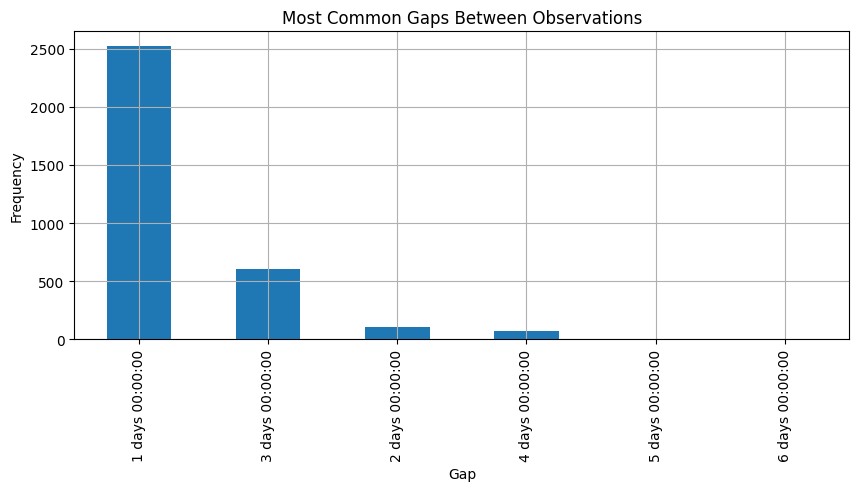

In [5]:
gap_counts = df.index.to_series().diff().value_counts().head(10)
display(gap_counts)

plt.figure(figsize=(10, 4))
gap_counts.plot(kind="bar")
plt.title("Most Common Gaps Between Observations")
plt.xlabel("Gap")
plt.ylabel("Frequency")
plt.show()

|      Gap | Meaning                                     |
| -------: | ------------------------------------------- |
|    1 day | Normal consecutive trading days             |
|   2 days | One missing calendar day, often a holiday   |
|   3 days | Usually weekend gap, Friday to Monday       |
| 4–6 days | Extended holidays or longer market closures |


### Raw time series visualization

Before modelling, the raw `Close` price must be visualized.  
This is where the main issue appears: there is a large one-day price scale break around September 2010.

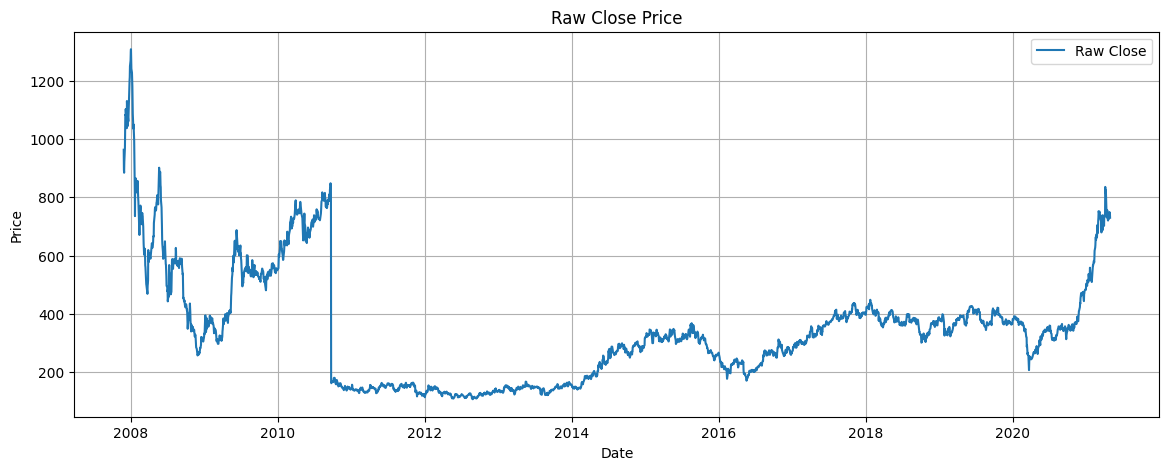

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Close"], label="Raw Close")
plt.title("Raw Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

Adani Ports had a 5:1 stock split around 23 September 2010.

In [7]:
df["raw_return"] = df["Close"].pct_change()
large_negative_moves = df[df["raw_return"] < -0.50][["Close", "raw_return"]]

display(large_negative_moves)

for event_date in large_negative_moves.index:
    prev_close = df["Close"].shift(1).loc[event_date]
    curr_close = df["Close"].loc[event_date]
    ratio = prev_close / curr_close
    print(f"Detected event: {event_date.date()}")
    print(f"Previous close: {prev_close:.2f}")
    print(f"Current close:  {curr_close:.2f}")
    print(f"Previous/current ratio: {ratio:.3f}")
    print(f"Nearest integer factor: {round(ratio)}")

,Close,raw_return
Date,,
2010-09-23,165.6000,-0.8022


Detected event: 2010-09-23
Previous close: 837.00
Current close:  165.60
Previous/current ratio: 5.054
Nearest integer factor: 5


### Fix: create an adjusted research series

The discontinuity around 2010-09-23 is approximately a 5:1 price scale break.  
To make the historical price path comparable through time, this notebook scales all prices **before** the event by `1 / factor`.

For example:

- Raw price before event: around `837`
- Raw price after event: around `165.6`
- Ratio: about `5.05`
- Adjustment: pre-event prices are divided by `5`

This makes the price path continuous and prevents the trend model from treating a scale adjustment as an economic crash.

Volume is adjusted in the opposite direction for share-count comparability. Turnover is not adjusted because price × volume should already remain economically comparable.

In [8]:
market_df = df.copy()

price_cols = [c for c in ["Prev Close", "Open", "High", "Low", "Last", "Close", "VWAP"] if c in market_df.columns]
share_volume_cols = [c for c in ["Volume", "Deliverable Volume"] if c in market_df.columns]

market_df["price_adjustment_factor"] = 1.0

detected_adjustments = []

for event_date in large_negative_moves.index:
    previous_close = market_df["Close"].shift(1).loc[event_date]
    current_close = market_df["Close"].loc[event_date]
    ratio = previous_close / current_close
    nearest_factor = int(round(ratio))

    # Accept only split-like ratios.
    if nearest_factor >= 2 and abs(ratio - nearest_factor) / nearest_factor <= 0.15:
        market_df.loc[market_df.index < event_date, "price_adjustment_factor"] /= nearest_factor
        detected_adjustments.append({
            "event_date": event_date,
            "previous_close": previous_close,
            "current_close": current_close,
            "ratio": ratio,
            "applied_factor": nearest_factor
        })

adjustment_table = pd.DataFrame(detected_adjustments)
display(adjustment_table)

for col in price_cols:
    clean_col = col.replace(" ", "_")
    market_df[f"Adj_{clean_col}"] = market_df[col] * market_df["price_adjustment_factor"]

# Volume adjustment: if pre-event prices are divided by factor, pre-event share counts are multiplied by factor.
market_df["volume_adjustment_factor"] = 1 / market_df["price_adjustment_factor"]

for col in share_volume_cols:
    clean_col = col.replace(" ", "_")
    market_df[f"Adj_{clean_col}"] = market_df[col] * market_df["volume_adjustment_factor"]

target_col = "Adj_Close"
market_df[target_col] = market_df["Adj_Close"]

print("Target column:", target_col)
display(market_df.loc["2010-09-20":"2010-09-24", ["Close", "Adj_Close", "Volume", "Adj_Volume"]])

,event_date,previous_close,current_close,ratio,applied_factor
0,2010-09-23,837.0000,165.6000,5.0543,5


Target column: Adj_Close


,Close,Adj_Close,Volume,Adj_Volume
Date,,,,
2010-09-20,848.1000,169.6200,434239,"2,171,195.0000"
2010-09-21,843.4000,168.6800,364314,"1,821,570.0000"
2010-09-22,837.0000,167.4000,205878,"1,029,390.0000"
2010-09-23,165.6000,165.6000,854754,"854,754.0000"
2010-09-24,162.8500,162.8500,1196835,"1,196,835.0000"


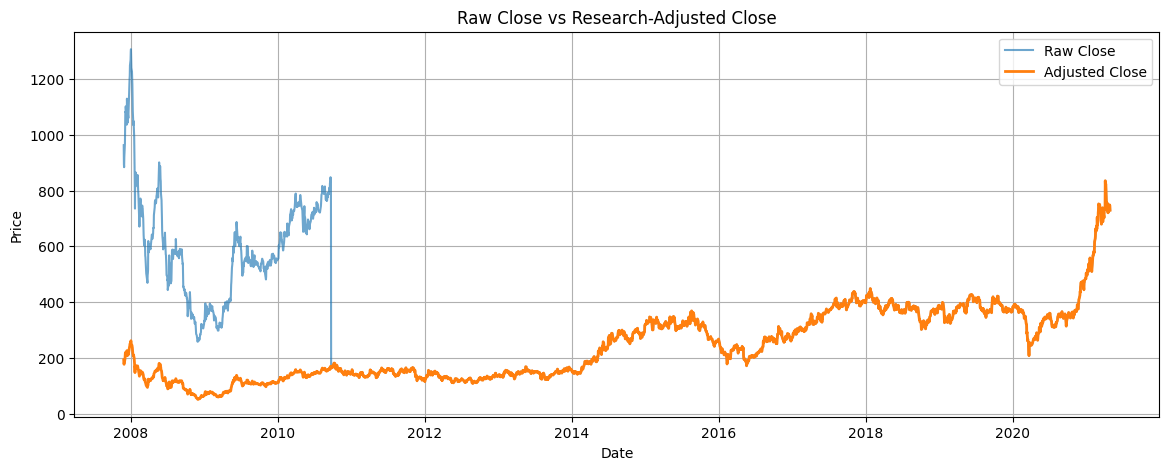

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(market_df.index, market_df["Close"], label="Raw Close", alpha=0.65)
plt.plot(market_df.index, market_df["Adj_Close"], label="Adjusted Close", linewidth=2)
plt.title("Raw Close vs Research-Adjusted Close")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

### Interpretation

The adjusted series changes the core conclusion:

- The **raw close** suggests the stock never recovered from its early high because the early price scale is inconsistent with the later price scale.
- The **adjusted close** shows a much clearer long-term upward price path.
- The earlier downward trend result was caused by treating a split-like scale break as real economic price movement.

This is the main reason the previous analysis looked wrong.

### Train-test split

A chronological split is required for time series forecasting.  
Random train-test splitting would leak future information into the training set.

Training period: 2007-11-27 to 2018-08-17 | n = 2657
Testing period:  2018-08-20 to 2021-04-30 | n = 665


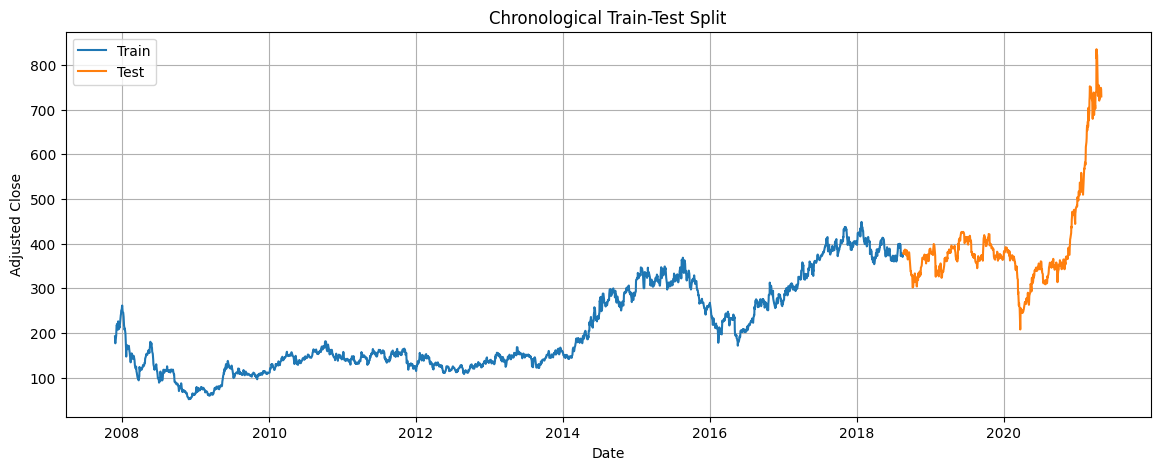

In [10]:
series = market_df["Adj_Close"].dropna()
log_price = np.log(series)
log_return = log_price.diff().dropna()

train_ratio = 0.80
split_idx = int(len(series) * train_ratio)

train = series.iloc[:split_idx]
test = series.iloc[split_idx:]

log_train = log_price.iloc[:split_idx]
log_test = log_price.iloc[split_idx:]

print("Training period:", train.index.min().date(), "to", train.index.max().date(), "| n =", len(train))
print("Testing period: ", test.index.min().date(), "to", test.index.max().date(), "| n =", len(test))

plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.title("Chronological Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Adjusted Close")
plt.legend()
plt.show()

## Part I.2 — Trend Analysis

Trend is analysed in three ways:

1. Visual inspection.
2. Moving average smoothing.
3. Linear regression slope estimation.

However, for this dataset, the most important point is that trend should not be evaluated only by a full-sample raw-price regression.  
The dataset contains structural regimes:

- IPO / early trading period.
- A split-like price scale adjustment.
- Long recovery phase.
- Recent sharp upward phase.

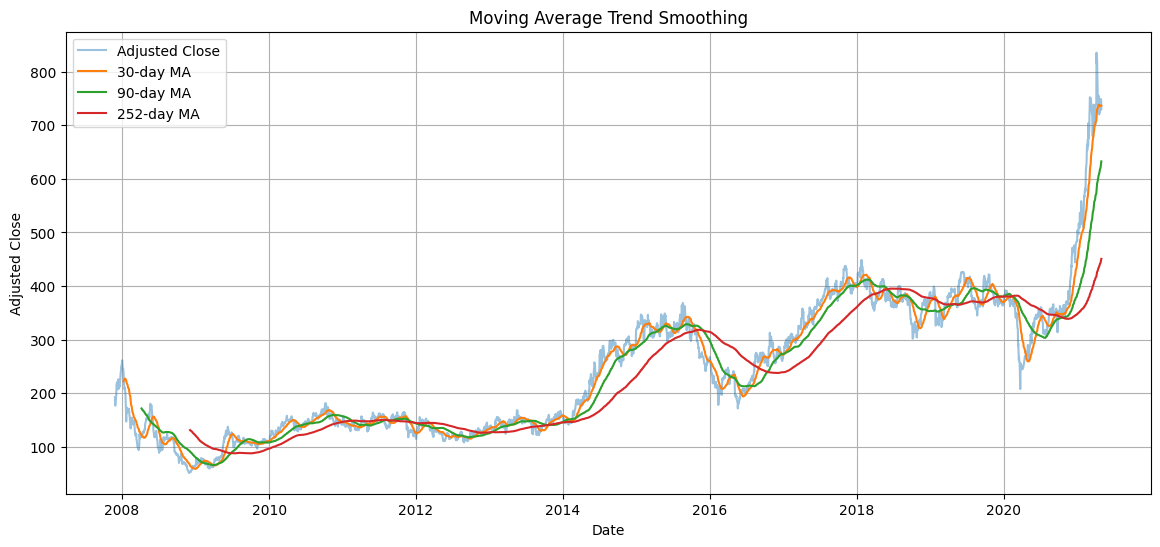

In [11]:
# Moving averages.
trend_df = market_df[["Close", "Adj_Close"]].copy()
trend_df["MA_30"] = trend_df["Adj_Close"].rolling(30).mean()
trend_df["MA_90"] = trend_df["Adj_Close"].rolling(90).mean()
trend_df["MA_252"] = trend_df["Adj_Close"].rolling(252).mean()

plt.figure(figsize=(14, 6))
plt.plot(trend_df.index, trend_df["Adj_Close"], label="Adjusted Close", alpha=0.45)
plt.plot(trend_df.index, trend_df["MA_30"], label="30-day MA")
plt.plot(trend_df.index, trend_df["MA_90"], label="90-day MA")
plt.plot(trend_df.index, trend_df["MA_252"], label="252-day MA")
plt.title("Moving Average Trend Smoothing")
plt.xlabel("Date")
plt.ylabel("Adjusted Close")
plt.legend()
plt.show()

In [12]:
def linear_trend_summary(series, name):
    s = pd.Series(series).dropna()
    x = np.arange(len(s))
    y = s.values

    result = linregress(x, y)

    return {
        "Segment": name,
        "Start": s.index.min().date(),
        "End": s.index.max().date(),
        "N": len(s),
        "Start Price": s.iloc[0],
        "End Price": s.iloc[-1],
        "Total Return %": (s.iloc[-1] / s.iloc[0] - 1) * 100,
        "Slope per Trading Day": result.slope,
        "Approx Annualized Slope": result.slope * 252,
        "R²": result.rvalue ** 2,
        "p-value": result.pvalue,
        "Trend Direction": "Upward" if result.slope > 0 else "Downward"
    }

segments = {
    "Raw Close Full Sample": market_df["Close"],
    "Adjusted Close Full Sample": market_df["Adj_Close"],
    "Adjusted Train Period": train,
    "Adjusted Test Period": test,
    "Post Split-like Event": market_df.loc["2010-09-23":, "Adj_Close"],
    "Recent 2019-2021": market_df.loc["2019":, "Adj_Close"],
}

trend_summary = pd.DataFrame([linear_trend_summary(v, k) for k, v in segments.items()])
display(trend_summary.round(4))

,Segment,Start,End,N,Start Price,End Price,Total Return %,Slope per Trading Day,Approx Annualized Slope,R²,p-value,Trend Direction
0,Raw Close Full Sample,2007-11-27,2021-04-30,3322,962.9000,730.0500,-24.1822,-0.0304,-7.6714,0.0229,0.0000,Downward
1,Adjusted Close Full Sample,2007-11-27,2021-04-30,3322,192.5800,730.0500,279.0892,0.1139,28.7066,0.7408,0.0000,Upward
2,Adjusted Train Period,2007-11-27,2018-08-17,2657,192.5800,374.1000,94.2569,0.1096,27.6166,0.7195,0.0000,Upward
3,Adjusted Test Period,2018-08-20,2021-04-30,665,378.2500,730.0500,93.0073,0.2745,69.1678,0.2389,0.0000,Upward
4,Post Split-like Event,2010-09-23,2021-04-30,2628,165.6000,730.0500,340.8514,0.1368,34.4738,0.7196,0.0000,Upward
5,Recent 2019-2021,2019-01-01,2021-04-30,577,389.0000,730.0500,87.6735,0.3393,85.5139,0.2467,0.0000,Upward


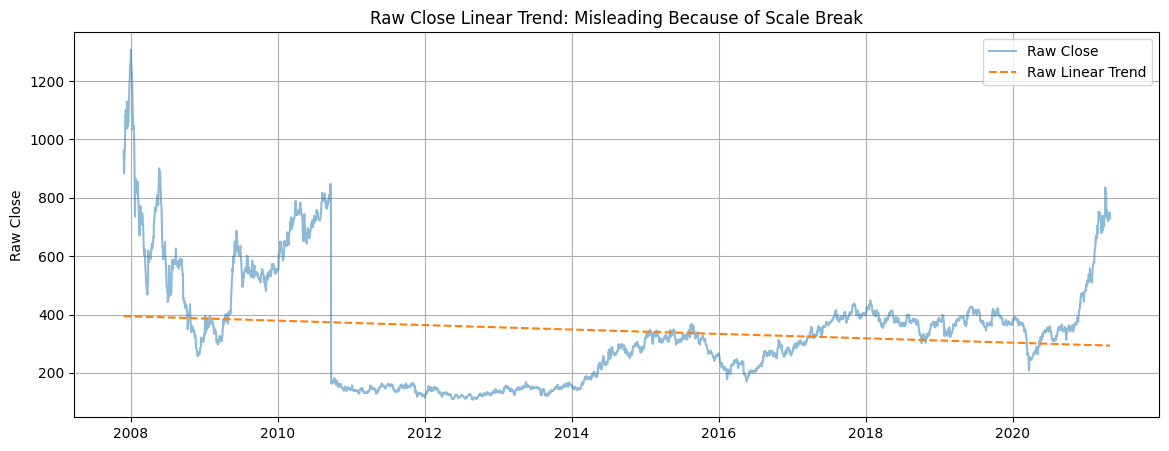

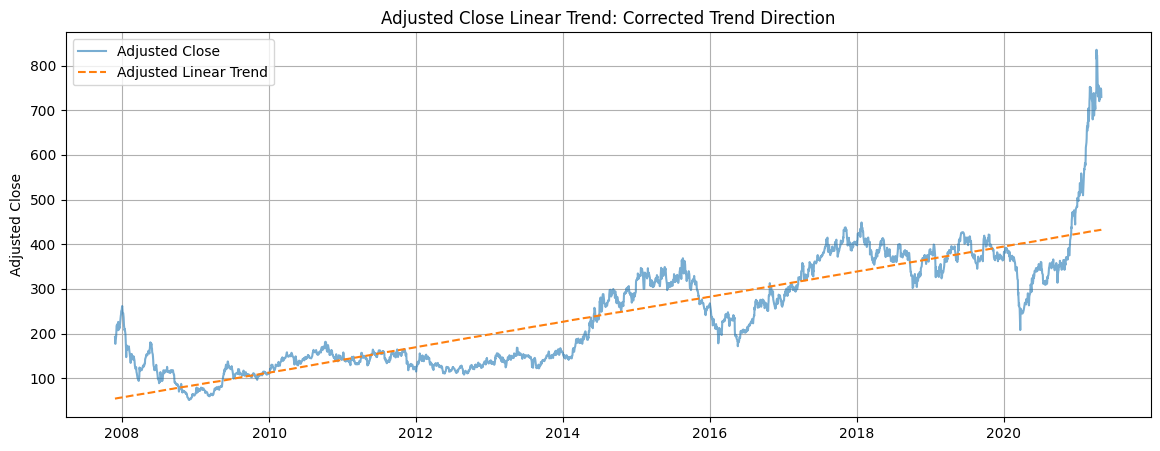

In [13]:
# Visual linear trend comparison: raw vs adjusted.
def add_regression_line(series, label):
    s = pd.Series(series).dropna()
    x = np.arange(len(s))
    fit = linregress(x, s.values)
    fitted = fit.intercept + fit.slope * x
    plt.plot(s.index, fitted, linestyle="--", label=label)

plt.figure(figsize=(14, 5))
plt.plot(market_df.index, market_df["Close"], alpha=0.5, label="Raw Close")
add_regression_line(market_df["Close"], "Raw Linear Trend")
plt.title("Raw Close Linear Trend: Misleading Because of Scale Break")
plt.ylabel("Raw Close")
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(market_df.index, market_df["Adj_Close"], alpha=0.6, label="Adjusted Close")
add_regression_line(market_df["Adj_Close"], "Adjusted Linear Trend")
plt.title("Adjusted Close Linear Trend: Corrected Trend Direction")
plt.ylabel("Adjusted Close")
plt.legend()
plt.show()

### Trend interpretation

The corrected trend analysis shows that the previous downward result was not a real long-term market conclusion.  
It was caused by two data issues:

1. The raw series contains an unadjusted split-like discontinuity.
2. The early IPO period had unusually high prices and different trading behavior.

After adjustment, the full-sample trend becomes upward.  
The recent test period also has an upward trend.

`Trades` should not be used to explain the pre-2011 period because it is missing before 2011-06-01.  
For participation analysis, use `Volume`, `Turnover`, `Deliverable Volume`, and `%Deliverble`, while treating `Trades` only as a post-2011 variable.

### Trading activity and participation analysis

The earlier statement about imbalanced trading activity is valid, but it needs to be handled carefully.

Important issues:

- Raw share volume is not directly comparable before and after a split-like adjustment.
- `Trades` is unavailable in the early period.
- `Turnover` is more economically comparable than raw share volume because it measures traded value.
- `%Deliverble` can indicate whether trading is dominated by delivery-based participation or short-term speculation.

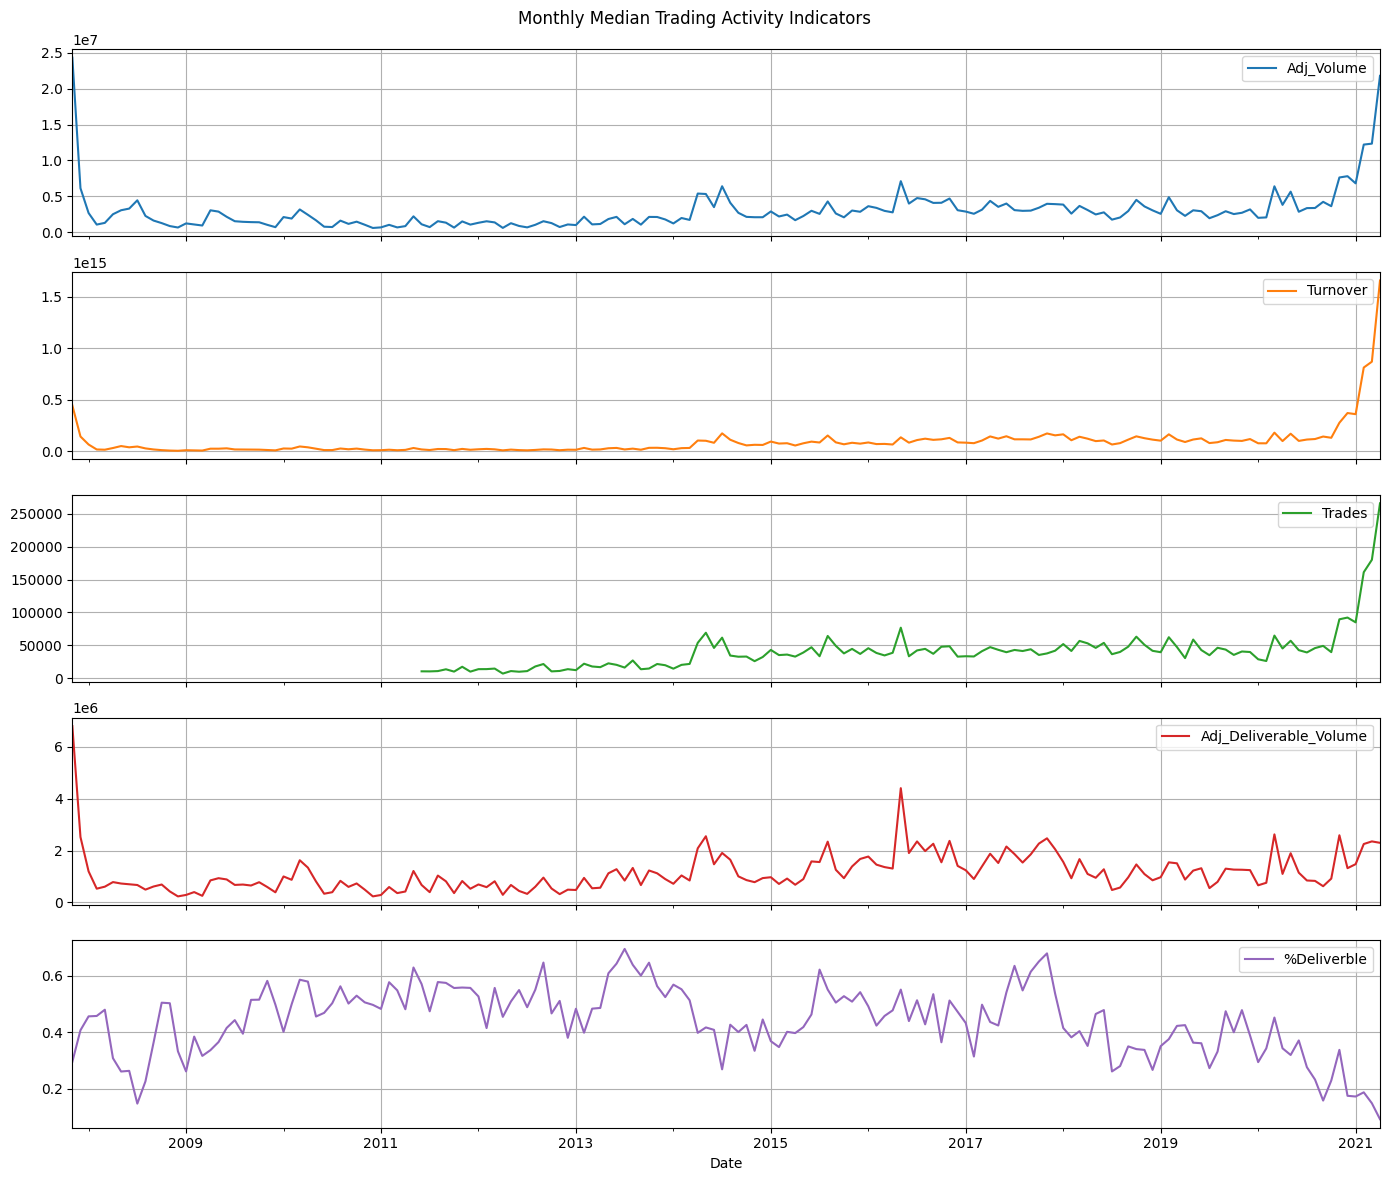

In [14]:
activity_cols = []

for col in ["Adj_Volume", "Turnover", "Trades", "Adj_Deliverable_Volume", "%Deliverble"]:
    if col in market_df.columns:
        activity_cols.append(col)

activity_df = market_df[activity_cols].copy()

# Use monthly medians to reduce noise from outlier trading days.
monthly_activity = activity_df.resample("ME").median()

axes = monthly_activity.plot(subplots=True, figsize=(14, 12), title="Monthly Median Trading Activity Indicators")
plt.tight_layout()
plt.show()

In [15]:
annual_summary = pd.DataFrame({
    "close_first": market_df["Adj_Close"].resample("YE").first(),
    "close_last": market_df["Adj_Close"].resample("YE").last(),
    "close_mean": market_df["Adj_Close"].resample("YE").mean(),
    "adj_volume_median": market_df["Adj_Volume"].resample("YE").median() if "Adj_Volume" in market_df.columns else np.nan,
    "turnover_median": market_df["Turnover"].resample("YE").median() if "Turnover" in market_df.columns else np.nan,
    "trades_median": market_df["Trades"].resample("YE").median() if "Trades" in market_df.columns else np.nan,
    "deliverable_pct_mean": market_df["%Deliverble"].resample("YE").mean() if "%Deliverble" in market_df.columns else np.nan,
})

annual_summary["annual_return_%"] = (annual_summary["close_last"] / annual_summary["close_first"] - 1) * 100
annual_summary.index = annual_summary.index.year

display(annual_summary.round(3))

,close_first,close_last,close_mean,adj_volume_median,turnover_median,trades_median,deliverable_pct_mean,annual_return_%
Date,,,,,,,,
2007,192.5800,253.7600,214.5420,"7,335,155.0000","173,593,856,540,000.0000",NaN,0.3790,31.7690
2008,259.3700,65.0600,118.4330,"1,920,162.5000","22,578,770,880,000.0000",NaN,0.3630,-74.9160
2009,66.7600,110.6900,97.6630,"1,403,720.0000","13,470,030,690,000.0000",NaN,0.4330,65.8030
2010,111.3500,144.0500,146.6050,"1,411,681.0000","20,886,495,090,000.0000",NaN,0.5120,29.3670
2011,145.0500,120.0500,144.6840,"1,042,409.0000","14,519,487,865,000.0000","11,334.0000",0.5500,-17.2350
2012,114.7000,135.0000,127.0310,"1,031,669.0000","12,899,878,390,000.0000","12,370.0000",0.5050,17.6980
2013,137.8000,155.4000,145.5580,"1,557,776.5000","22,168,817,965,000.0000","19,057.0000",0.5630,12.7720
2014,156.3000,319.0500,233.5430,"2,759,677.5000","68,767,706,635,000.0000","34,188.0000",0.4360,104.1270
2015,319.5500,260.9000,314.6320,"2,600,796.0000","82,710,437,040,000.0000","40,701.5000",0.4790,-18.3540


### Trading activity interpretation

Use the table above to describe the changing participation regime.

Typical findings in this dataset:

- Early years have missing `Trades`, so trade-count comparisons must begin only after 2011-06-01.
- The 2021 period has a large increase in median volume, turnover, and trades, consistent with stronger market participation.
- `%Deliverble` declines in some high-activity periods, suggesting that a larger share of trading may be short-term or intraday rather than delivery-oriented.
- Therefore, the trend is not simply a straight line. It is affected by market participation, structural breaks, and a change in trading regime.

## Part I.3 — Seasonality Analysis

Stock prices usually do not exhibit strong deterministic seasonality like monthly sales or climate data.  
For equities, seasonality should be checked on **returns**, not only on price levels, because price levels are dominated by trend.

This notebook checks:

1. Day-of-week return effects.
2. Month-of-year return effects.
3. Seasonal decomposition with trading-day periods.

,mean,median,std,count
day_name,,,,
Monday,-0.0001,0.0000,0.0309,659
Tuesday,0.0015,0.0005,0.0271,667
Wednesday,0.0004,-0.0003,0.0269,669
Thursday,-0.0001,-0.0004,0.0245,659
Friday,0.0005,0.0003,0.0249,653


,mean,median,std,count
month,,,,
April,0.0030,0.0021,0.0250,265
August,0.0012,0.0001,0.0255,270
December,0.0024,0.0005,0.0234,294
February,-0.0002,-0.0019,0.0257,278
January,-0.0000,-0.0009,0.0330,300
July,0.0002,0.0002,0.0265,288
June,-0.0011,0.0000,0.0218,276
March,-0.0005,0.0004,0.0324,286
May,0.0026,0.0010,0.0311,276


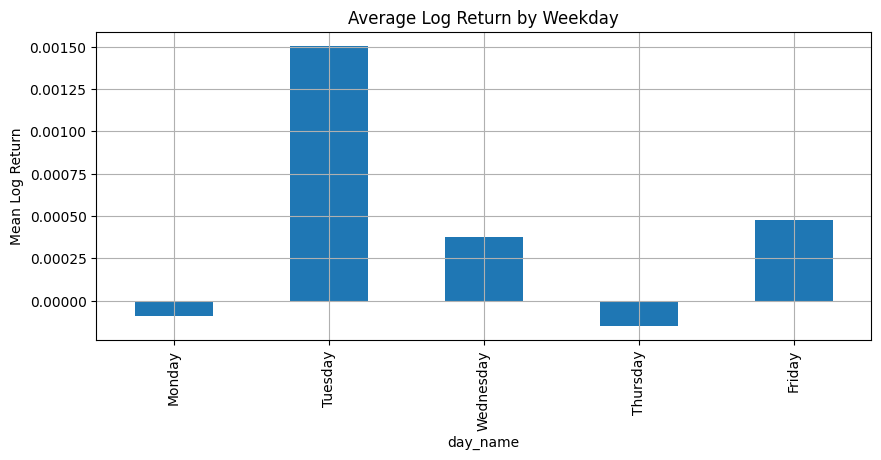

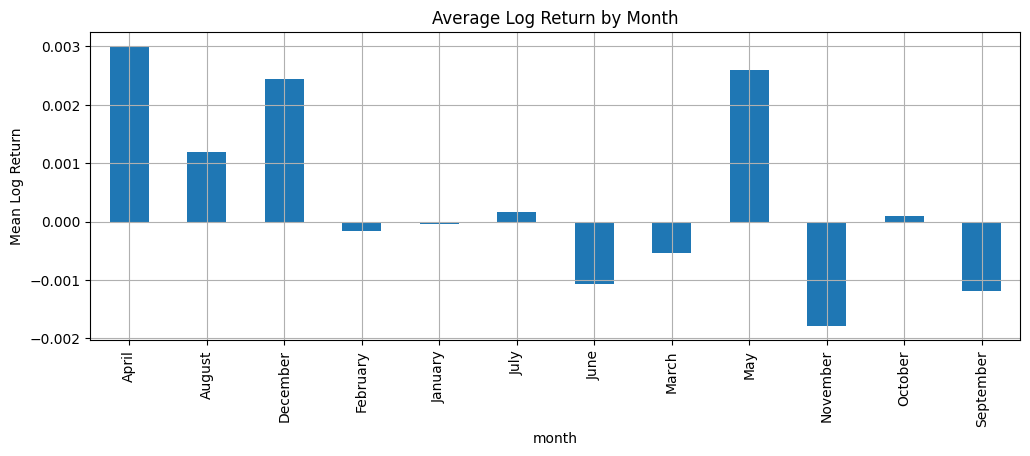

In [16]:
returns_df = pd.DataFrame({
    "log_return": np.log(market_df["Adj_Close"]).diff()
}).dropna()

returns_df["day_name"] = returns_df.index.day_name()
returns_df["month"] = returns_df.index.month_name()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

weekday_returns = returns_df.groupby("day_name")["log_return"].agg(["mean", "median", "std", "count"]).reindex(weekday_order)
monthly_returns = returns_df.groupby("month")["log_return"].agg(["mean", "median", "std", "count"])

display(weekday_returns.round(6))
display(monthly_returns.round(6))

plt.figure(figsize=(10, 4))
weekday_returns["mean"].plot(kind="bar")
plt.title("Average Log Return by Weekday")
plt.ylabel("Mean Log Return")
plt.show()

plt.figure(figsize=(12, 4))
monthly_returns["mean"].plot(kind="bar")
plt.title("Average Log Return by Month")
plt.ylabel("Mean Log Return")
plt.show()

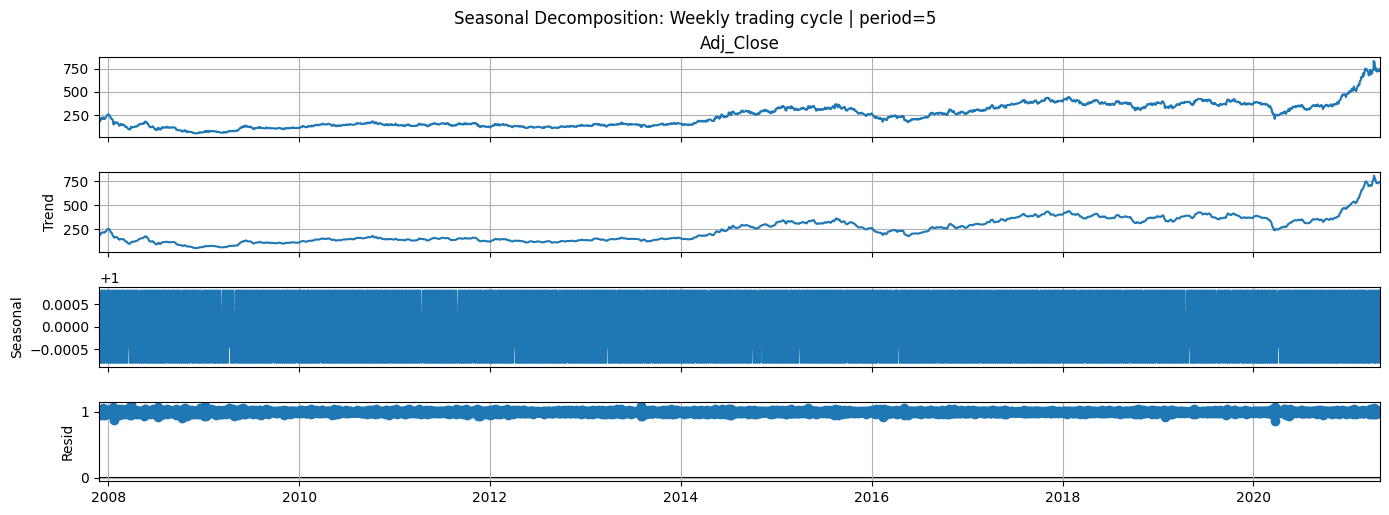

Weekly trading cycle seasonal strength estimate: 0.0011


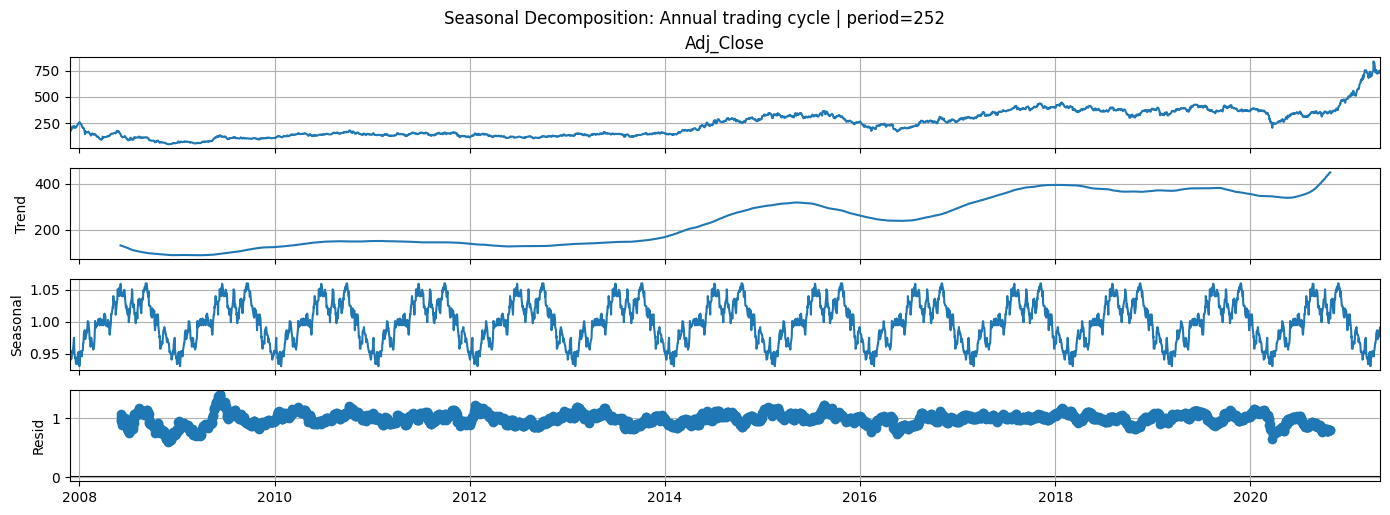

Annual trading cycle seasonal strength estimate: 0.1011


In [17]:
# Seasonal decomposition on adjusted close.
# period=252 approximates one trading year.
# period=5 approximates one trading week.

decomp_series = market_df["Adj_Close"].dropna()

for seasonal_period, label in [(5, "Weekly trading cycle"), (252, "Annual trading cycle")]:
    if len(decomp_series) > 2 * seasonal_period:
        result = seasonal_decompose(decomp_series, model="multiplicative", period=seasonal_period)
        result.plot()
        plt.suptitle(f"Seasonal Decomposition: {label} | period={seasonal_period}", y=1.02)
        plt.show()

        seasonal_strength = 1 - np.nanvar(result.resid) / np.nanvar(result.seasonal + result.resid)
        print(f"{label} seasonal strength estimate:", round(seasonal_strength, 4))

### Seasonality interpretation

The adjusted close series may show weak calendar patterns, but the dominant components are trend and volatility.  
For modelling, the most defensible conclusion is:

- There is **no strong deterministic seasonality** comparable to monthly or quarterly business data.
- If a seasonal period must be specified for market-calendar analysis:
  - `5` trading days represents a weekly trading cycle.
  - `252` trading days approximates a trading year.
- For ARIMA-style forecasting in this assignment, non-seasonal models are more appropriate unless the decomposition shows strong seasonal strength.

## Part I.4 — Stationarity Analysis

Stationarity is evaluated using:

1. Rolling mean.
2. Rolling standard deviation.
3. Augmented Dickey-Fuller test.
4. KPSS test.

Interpretation rules:

| Test | Null hypothesis | Desired result for stationarity |
|---|---|---|
| ADF | Series has a unit root / non-stationary | p-value < 0.05 |
| KPSS | Series is stationary | p-value > 0.05 |

For stock data, the adjusted price level is usually non-stationary, while log returns are often stationary.

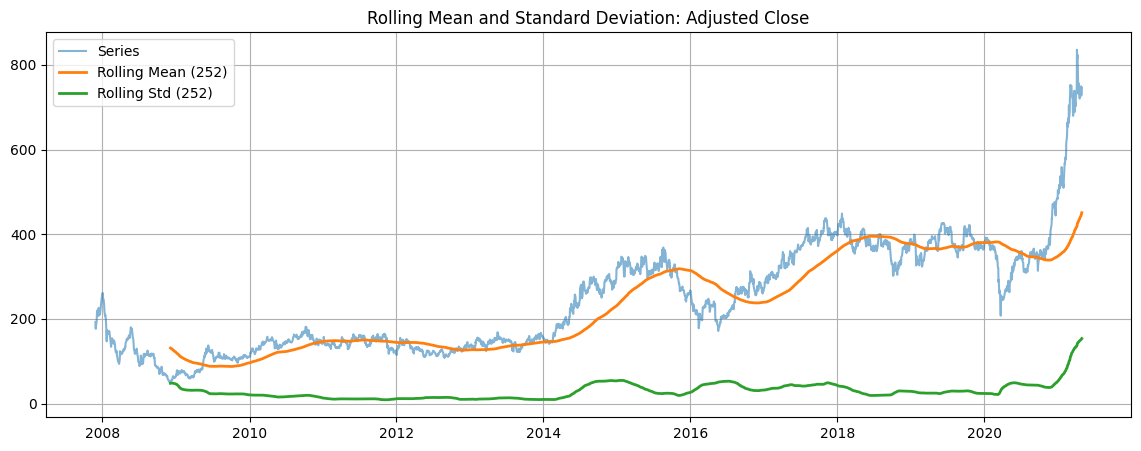

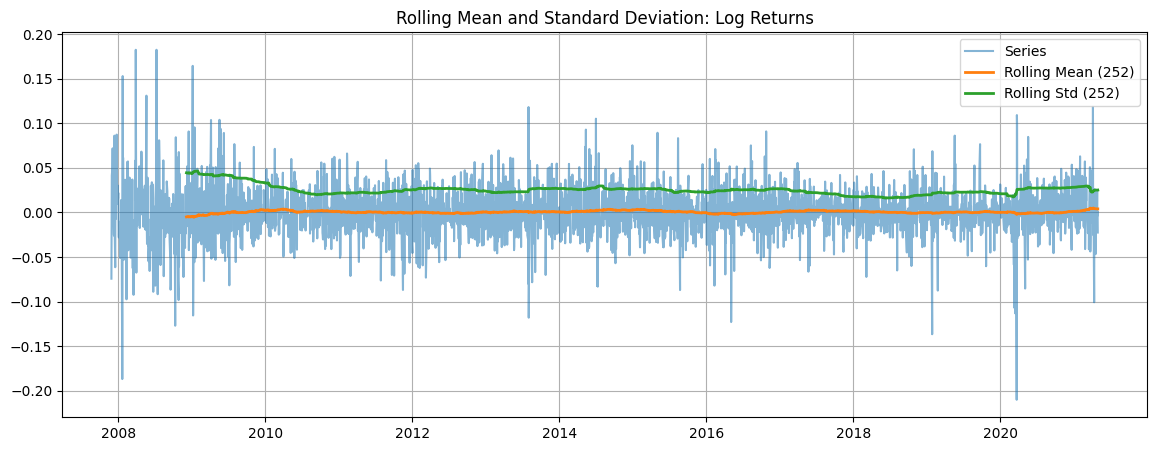

C:\Users\rubin\AppData\Local\Temp\ipykernel_14676\3768878753.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(s, regression=regression_for_kpss, nlags="auto")
C:\Users\rubin\AppData\Local\Temp\ipykernel_14676\3768878753.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(s, regression=regression_for_kpss, nlags="auto")
C:\Users\rubin\AppData\Local\Temp\ipykernel_14676\3768878753.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(s, regression=regression_for_kpss, nlags="auto")


,Series,N,ADF Statistic,ADF p-value,ADF Conclusion,KPSS Statistic,KPSS p-value,KPSS Conclusion
0,Adjusted Close,3322,1.0150,0.9944,Non-stationary,7.0274,0.0100,Non-stationary
1,Log Adjusted Close,3322,-0.5333,0.8853,Non-stationary,7.3891,0.0100,Non-stationary
2,Log Return / First Difference of Log Price,3321,-57.7537,0.0000,Stationary,0.1676,0.1000,Stationary


In [18]:
def run_stationarity_tests(series, name, regression_for_kpss="c"):
    s = pd.Series(series).dropna()

    result = {
        "Series": name,
        "N": len(s)
    }

    try:
        adf_result = adfuller(s, autolag="AIC")
        result["ADF Statistic"] = adf_result[0]
        result["ADF p-value"] = adf_result[1]
        result["ADF Conclusion"] = "Stationary" if adf_result[1] < 0.05 else "Non-stationary"
    except Exception as e:
        result["ADF Statistic"] = np.nan
        result["ADF p-value"] = np.nan
        result["ADF Conclusion"] = f"Failed: {e}"

    try:
        kpss_result = kpss(s, regression=regression_for_kpss, nlags="auto")
        result["KPSS Statistic"] = kpss_result[0]
        result["KPSS p-value"] = kpss_result[1]
        result["KPSS Conclusion"] = "Stationary" if kpss_result[1] > 0.05 else "Non-stationary"
    except Exception as e:
        result["KPSS Statistic"] = np.nan
        result["KPSS p-value"] = np.nan
        result["KPSS Conclusion"] = f"Failed: {e}"

    return result


def plot_rolling_stats(series, title, window=252):
    s = pd.Series(series).dropna()

    rolling_mean = s.rolling(window).mean()
    rolling_std = s.rolling(window).std()

    plt.figure(figsize=(14, 5))
    plt.plot(s, label="Series", alpha=0.55)
    plt.plot(rolling_mean, label=f"Rolling Mean ({window})", linewidth=2)
    plt.plot(rolling_std, label=f"Rolling Std ({window})", linewidth=2)
    plt.title(title)
    plt.legend()
    plt.show()


plot_rolling_stats(market_df["Adj_Close"], "Rolling Mean and Standard Deviation: Adjusted Close", window=252)
plot_rolling_stats(np.log(market_df["Adj_Close"]).diff(), "Rolling Mean and Standard Deviation: Log Returns", window=252)

stationarity_initial = pd.DataFrame([
    run_stationarity_tests(market_df["Adj_Close"], "Adjusted Close"),
    run_stationarity_tests(np.log(market_df["Adj_Close"]), "Log Adjusted Close"),
    run_stationarity_tests(np.log(market_df["Adj_Close"]).diff(), "Log Return / First Difference of Log Price"),
])

display(stationarity_initial.round(5))

### Stationarity interpretation

Expected interpretation for this dataset:

- Adjusted close price is non-stationary.
- Log adjusted close is also non-stationary.
- First-differenced log price, i.e. log return, is stationary.

Therefore:

- Use price levels for visualization and final price forecasts.
- Use log returns for ACF/PACF interpretation and AR/MA/ARMA modelling.
- Use ARIMA with `d=1` on log price to account for non-stationarity.

# Part II — Time Series Transformation

The following transformations are applied:

1. Log transformation.
2. Linear trend removal.
3. First differencing.
4. Seasonal differencing.

After each transformation, ADF and KPSS tests are repeated.

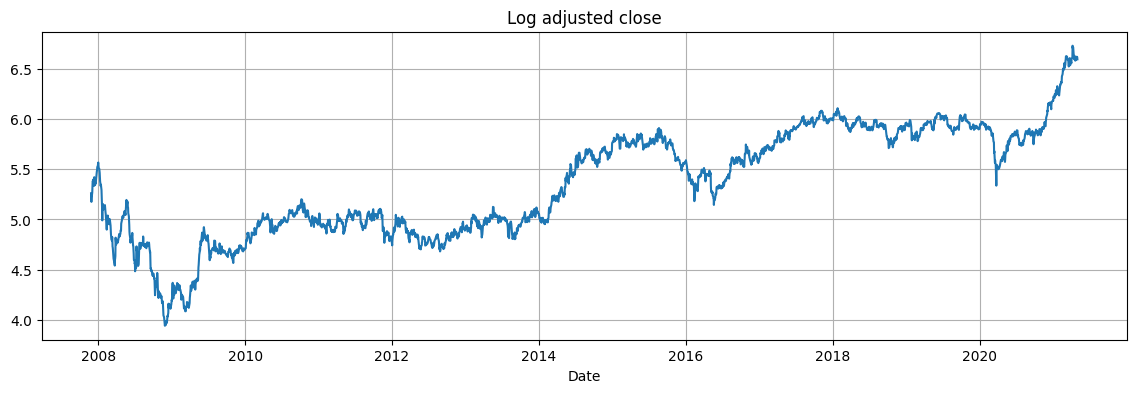

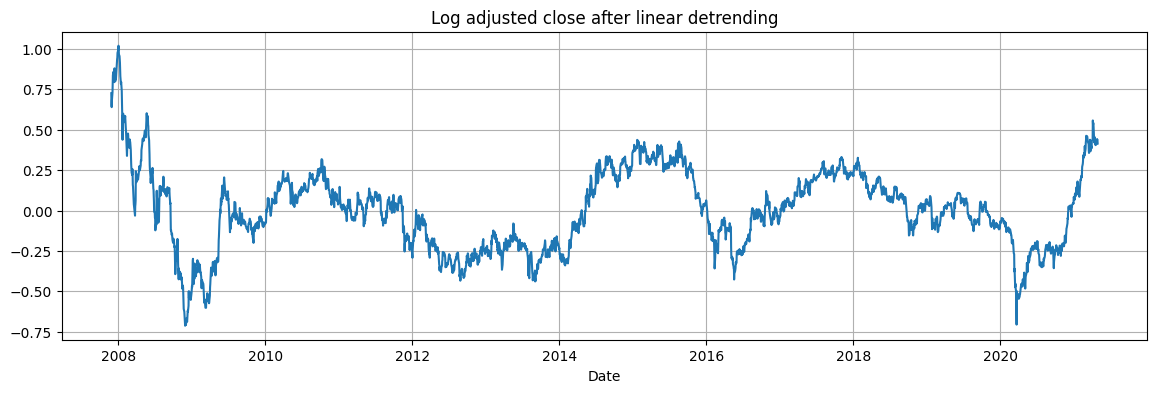

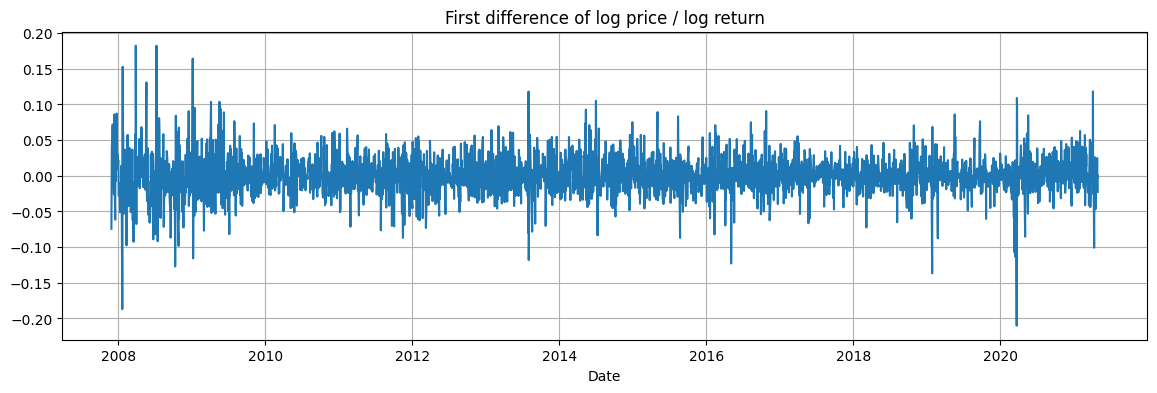

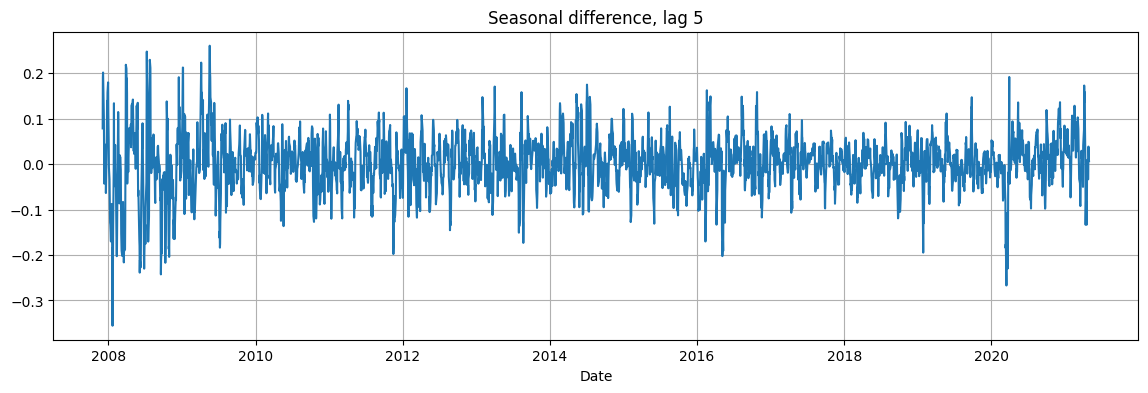

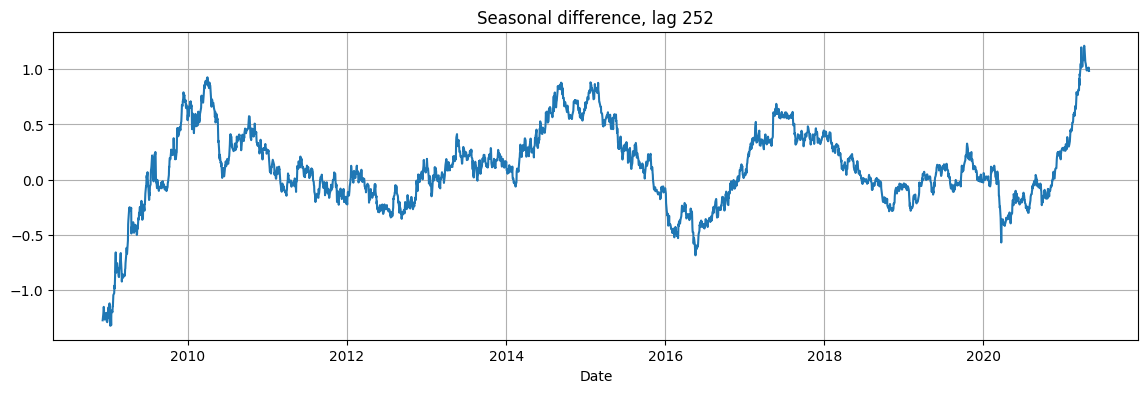

C:\Users\rubin\AppData\Local\Temp\ipykernel_14676\3768878753.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(s, regression=regression_for_kpss, nlags="auto")
C:\Users\rubin\AppData\Local\Temp\ipykernel_14676\3768878753.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(s, regression=regression_for_kpss, nlags="auto")
C:\Users\rubin\AppData\Local\Temp\ipykernel_14676\3768878753.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(s, regression=regression_for_kpss, nlags="auto")
C:\Users\rubin\AppData\Local\Temp\ipykernel_14676\3768878753.py:20: InterpolationWarn

,Series,N,ADF Statistic,ADF p-value,ADF Conclusion,KPSS Statistic,KPSS p-value,KPSS Conclusion
0,Log adjusted close,3322,-0.5333,0.8853,Non-stationary,7.3891,0.0100,Non-stationary
1,Log adjusted close after linear detrending,3322,-3.6092,0.0056,Stationary,0.2515,0.1000,Stationary
2,First difference of log price / log return,3321,-57.7537,0.0000,Stationary,0.1676,0.1000,Stationary
3,"Seasonal difference, lag 5",3317,-10.9144,0.0000,Stationary,0.1643,0.1000,Stationary
4,"Seasonal difference, lag 252",3070,-3.6640,0.0046,Stationary,0.2501,0.1000,Stationary


In [19]:
log_adjusted_close = np.log(market_df["Adj_Close"])

# Linear detrending of log price.
x = np.arange(len(log_adjusted_close))
trend_fit = linregress(x, log_adjusted_close.values)
linear_trend = pd.Series(trend_fit.intercept + trend_fit.slope * x, index=log_adjusted_close.index)
log_detrended = log_adjusted_close - linear_trend

first_diff_log = log_adjusted_close.diff()
seasonal_diff_5 = log_adjusted_close.diff(5)
seasonal_diff_252 = log_adjusted_close.diff(252)

transformed_series = {
    "Log adjusted close": log_adjusted_close,
    "Log adjusted close after linear detrending": log_detrended,
    "First difference of log price / log return": first_diff_log,
    "Seasonal difference, lag 5": seasonal_diff_5,
    "Seasonal difference, lag 252": seasonal_diff_252,
}

for name, s in transformed_series.items():
    plt.figure(figsize=(14, 4))
    plt.plot(s)
    plt.title(name)
    plt.xlabel("Date")
    plt.show()

transformation_tests = pd.DataFrame([
    run_stationarity_tests(s, name)
    for name, s in transformed_series.items()
])

display(transformation_tests.round(5))

### Transformation conclusion

The correct stationary series for modelling is the **first difference of log adjusted close**, also known as the log return.

This transformation works because:

\[
r_t = \log(P_t) - \log(P_{t-1})
\]

It removes the stochastic trend from the price level and converts the series into daily percentage-like changes.

Seasonal differencing may also pass stationarity tests, but for stock prices it is less theoretically appropriate than first differencing unless strong seasonality is proven.

# Part III — ACF and PACF Analysis

ACF and PACF should be applied to the stationary series, not to the raw price level.

- ACF helps identify MA(q) behavior.
- PACF helps identify AR(p) behavior.

For stock returns, it is common to find weak autocorrelation, meaning price direction is difficult to predict from past returns alone.

<Figure size 1400x400 with 0 Axes>

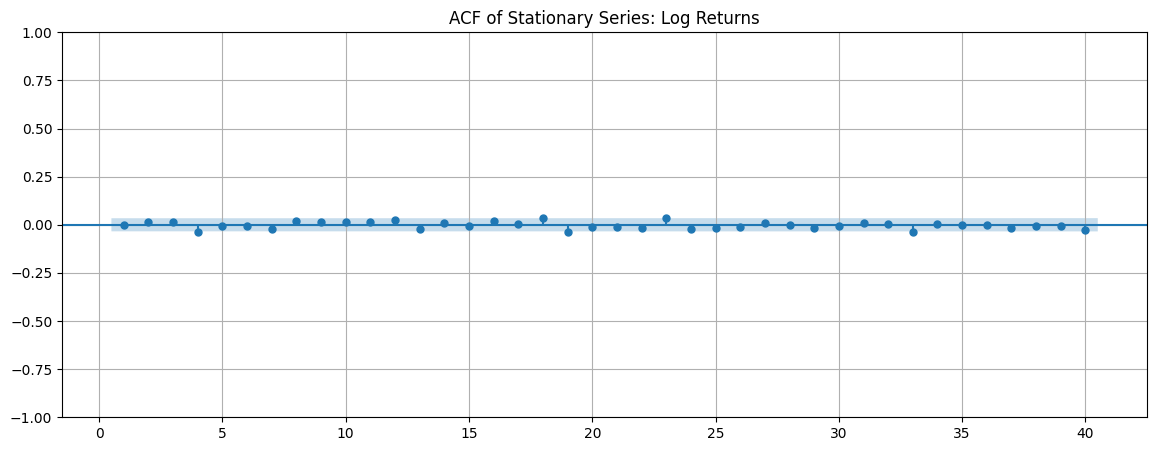

<Figure size 1400x400 with 0 Axes>

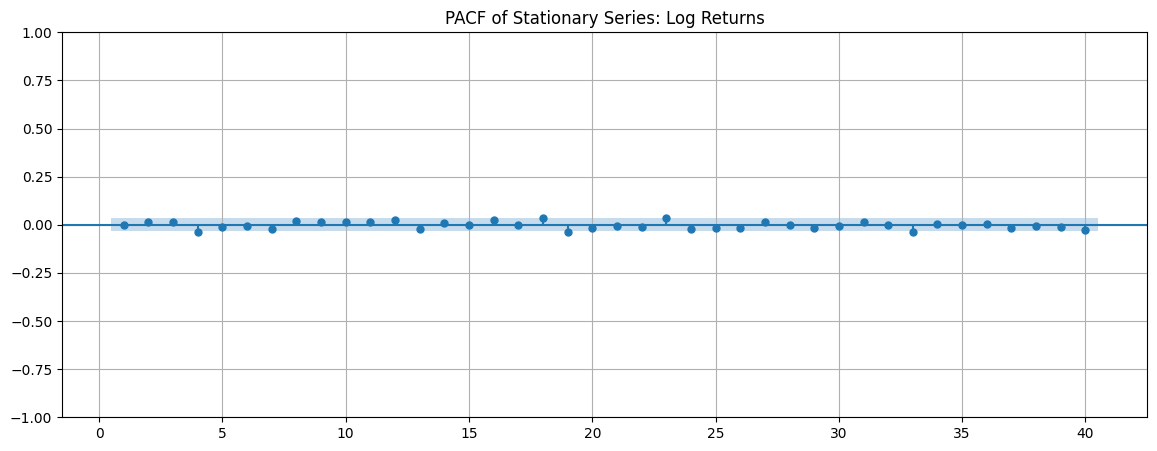

Approximate 95% confidence limit: 0.034
Significant ACF lags: [4, 18, 19, 23, 33]
Significant PACF lags: [4, 18, 19, 23, 33]


,lb_stat,lb_pvalue
5,5.7669,0.3296
10,10.6434,0.3860
20,26.5890,0.1472


In [20]:
stationary_series = first_diff_log.dropna()
stationary_series.name = "log_return"

max_lags = 40

plt.figure(figsize=(14, 4))
plot_acf(stationary_series, lags=max_lags, zero=False)
plt.title("ACF of Stationary Series: Log Returns")
plt.show()

plt.figure(figsize=(14, 4))
plot_pacf(stationary_series, lags=max_lags, zero=False, method="ywm")
plt.title("PACF of Stationary Series: Log Returns")
plt.show()

n_obs = len(stationary_series)
conf_limit = 1.96 / np.sqrt(n_obs)

acf_values = acf(stationary_series, nlags=max_lags, fft=True)
pacf_values = pacf(stationary_series, nlags=max_lags, method="ywm")

significant_acf_lags = [lag for lag in range(1, max_lags + 1) if abs(acf_values[lag]) > conf_limit]
significant_pacf_lags = [lag for lag in range(1, max_lags + 1) if abs(pacf_values[lag]) > conf_limit]

print("Approximate 95% confidence limit:", round(conf_limit, 4))
print("Significant ACF lags:", significant_acf_lags)
print("Significant PACF lags:", significant_pacf_lags)

lb = acorr_ljungbox(stationary_series, lags=[5, 10, 20], return_df=True)
display(lb)

In [21]:
def choose_low_order(significant_lags, default=1, max_allowed=5):
    """
    Select a conservative low order.
    If lag 1 is significant, use 1.
    If only isolated higher lags are significant, keep model simple.
    """
    if 1 in significant_lags:
        return 1

    nearby_lags = [lag for lag in significant_lags if lag <= max_allowed]
    if len(nearby_lags) > 0:
        return min(nearby_lags)

    return default

p_order = choose_low_order(significant_pacf_lags, default=1)
q_order = choose_low_order(significant_acf_lags, default=1)

d_order = 1

print("Selected AR order p:", p_order)
print("Selected differencing order d:", d_order)
print("Selected MA order q:", q_order)

Selected AR order p: 4
Selected differencing order d: 1
Selected MA order q: 4


### ACF/PACF interpretation and model order selection

The selected orders are deliberately conservative.

If the ACF/PACF plots show only weak or isolated significant lags, the correct interpretation is not to build an unnecessarily complex model.  
In financial return series, isolated significant lags often occur by chance.

Therefore:

- `p` is selected from PACF behavior.
- `q` is selected from ACF behavior.
- `d=1` is used for ARIMA on log prices because the price level is non-stationary but log returns are stationary.

If the Ljung-Box p-values are large, the stationary return series is close to white noise. In that case, AR/MA/ARMA models may not outperform a naive random walk forecast.

# Part IV — Classical Time Series Forecasting Models

Models implemented:

1. AR model on log returns.
2. MA model on log returns.
3. ARMA model on log returns.
4. ARIMA model on log price.

Why this structure?

- AR, MA, and ARMA require stationary data, so they are fitted to log returns.
- ARIMA includes differencing internally, so it is fitted to log price with `d=1`.
- Forecasted log returns are converted back into price paths for evaluation.

In [22]:
def log_return_forecast_to_price(forecasted_log_returns, last_train_price, forecast_index):
    """
    Converts predicted log returns into a price path.
    """
    forecasted_log_returns = pd.Series(np.asarray(forecasted_log_returns).ravel(), index=forecast_index)
    forecasted_log_price = np.log(last_train_price) + forecasted_log_returns.cumsum()
    forecasted_price = np.exp(forecasted_log_price)
    return pd.Series(forecasted_price, index=forecast_index)


def fit_arima_safely(series, order, trend="c", model_name="model"):
    """
    Fits ARIMA robustly. If convergence warnings occur, the model may still produce usable forecasts.
    """
    try:
        model = ARIMA(series, order=order, trend=trend)
        fitted = model.fit(method_kwargs={"maxiter": 200})
        print(f"{model_name} fitted successfully. AIC={fitted.aic:.3f}, BIC={fitted.bic:.3f}")
        return fitted
    except Exception as e:
        print(f"{model_name} failed:", e)
        return None


def safe_forecast(fitted_model, steps):
    if fitted_model is None:
        return None
    try:
        return fitted_model.forecast(steps=steps)
    except Exception as e:
        print("Forecast failed:", e)
        return None


train_log_price = np.log(train)
test_log_price = np.log(test)

train_log_returns = train_log_price.diff().dropna()

forecast_horizon = len(test)
forecast_index = test.index
last_train_price = train.iloc[-1]

forecasts = {}
fitted_models = {}

# Naive baseline: next price equals last training price.
forecasts["Naive"] = pd.Series(last_train_price, index=forecast_index)

# 1. AR(p) on log returns.
ar_model = fit_arima_safely(train_log_returns, order=(p_order, 0, 0), trend="c", model_name=f"AR({p_order})")
fitted_models["AR"] = ar_model
ar_returns_forecast = safe_forecast(ar_model, forecast_horizon)
if ar_returns_forecast is not None:
    forecasts["AR"] = log_return_forecast_to_price(ar_returns_forecast, last_train_price, forecast_index)

# 2. MA(q) on log returns.
ma_model = fit_arima_safely(train_log_returns, order=(0, 0, q_order), trend="c", model_name=f"MA({q_order})")
fitted_models["MA"] = ma_model
ma_returns_forecast = safe_forecast(ma_model, forecast_horizon)
if ma_returns_forecast is not None:
    forecasts["MA"] = log_return_forecast_to_price(ma_returns_forecast, last_train_price, forecast_index)

# 3. ARMA(p, q) on log returns.
arma_model = fit_arima_safely(train_log_returns, order=(p_order, 0, q_order), trend="c", model_name=f"ARMA({p_order},{q_order})")
fitted_models["ARMA"] = arma_model
arma_returns_forecast = safe_forecast(arma_model, forecast_horizon)
if arma_returns_forecast is not None:
    forecasts["ARMA"] = log_return_forecast_to_price(arma_returns_forecast, last_train_price, forecast_index)

# 4. ARIMA(p, d, q) on log price.
# trend="n" is used because differencing already handles stochastic trend.
arima_model = fit_arima_safely(train_log_price, order=(p_order, d_order, q_order), trend="n", model_name=f"ARIMA({p_order},{d_order},{q_order})")
fitted_models["ARIMA"] = arima_model
arima_log_forecast = safe_forecast(arima_model, forecast_horizon)
if arima_log_forecast is not None:
    forecasts["ARIMA"] = pd.Series(np.exp(np.asarray(arima_log_forecast).ravel()), index=forecast_index)

print("Available forecasts:", list(forecasts.keys()))

c:\Users\rubin\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\rubin\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\rubin\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


AR(4) fitted successfully. AIC=-11590.180, BIC=-11554.873


c:\Users\rubin\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\rubin\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\rubin\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\rubin\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forec

MA(4) fitted successfully. AIC=-11589.774, BIC=-11554.466


c:\Users\rubin\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\rubin\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\rubin\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\rubin\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forec

ARMA(4,4) fitted successfully. AIC=-11586.760, BIC=-11527.914


c:\Users\rubin\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\rubin\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\rubin\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\rubin\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forec

ARIMA(4,1,4) fitted successfully. AIC=-11587.167, BIC=-11534.206
Available forecasts: ['Naive', 'AR', 'MA', 'ARMA', 'ARIMA']


c:\Users\rubin\anaconda3\envs\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


### How differencing contributes to ARIMA

ARIMA includes the `I` component, which stands for **Integrated**.  
The differencing order `d` transforms a non-stationary level series into a stationary difference series.

For this dataset:

- Adjusted close is non-stationary.
- Log adjusted close is non-stationary.
- First-differenced log adjusted close is stationary.

Therefore, `d=1` is appropriate for ARIMA on log prices.

## Classical model residual analysis

Residuals are checked using:

1. Residual time plot.
2. Histogram.
3. Residual ACF.
4. Ljung-Box test.

A good model should leave residuals with little autocorrelation.  
In financial forecasting, residuals often still show volatility clustering even when mean autocorrelation is weak.

In [23]:
def clean_series(values, name=None):
    if values is None:
        return pd.Series(dtype=float, name=name)
    if isinstance(values, pd.Series):
        s = values.copy()
    elif isinstance(values, pd.DataFrame):
        s = values.iloc[:, 0].copy()
    else:
        s = pd.Series(np.asarray(values).ravel())
    s = pd.to_numeric(s, errors="coerce")
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    if name is not None:
        s.name = name
    return s


def align_actual_prediction(actual, predicted, model_name):
    actual_s = clean_series(actual, "Actual")
    pred_s = clean_series(predicted, model_name)

    if len(actual_s) == 0 or len(pred_s) == 0:
        return pd.DataFrame(columns=["Actual", model_name])

    common_index = actual_s.index.intersection(pred_s.index)

    if len(common_index) > 0:
        aligned = pd.concat([actual_s.loc[common_index], pred_s.loc[common_index]], axis=1)
    else:
        n = min(len(actual_s), len(pred_s))
        a = actual_s.iloc[-n:].copy()
        p = pred_s.iloc[-n:].copy()
        p.index = a.index
        aligned = pd.concat([a, p], axis=1)

    aligned.columns = ["Actual", model_name]
    aligned = aligned.replace([np.inf, -np.inf], np.nan).dropna()
    return aligned


def plot_residual_diagnostics(residuals, title, max_lags=40):
    residuals = clean_series(residuals, "Residual")

    if len(residuals) == 0:
        print(f"Skipping {title}: no valid residuals.")
        return

    plt.figure(figsize=(14, 4))
    plt.plot(residuals)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Residuals: {title}")
    plt.xlabel("Date / Observation")
    plt.ylabel("Residual")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(residuals, bins=30)
    plt.title(f"Residual Distribution: {title}")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.show()

    if len(residuals) >= 5 and residuals.std() > 0:
        lags = min(max_lags, len(residuals) - 1)
        plt.figure(figsize=(14, 4))
        plot_acf(residuals, lags=lags, zero=False)
        plt.title(f"Residual ACF: {title}")
        plt.show()

        lb_lags = [lag for lag in [5, 10, 20] if lag < len(residuals)]
        if len(lb_lags) > 0:
            display(acorr_ljungbox(residuals, lags=lb_lags, return_df=True))
    else:
        print(f"Skipping residual ACF for {title}: not enough valid non-constant residuals.")

AR
Residual mean: -9.728145604527867
Residual std: 99.6573823145


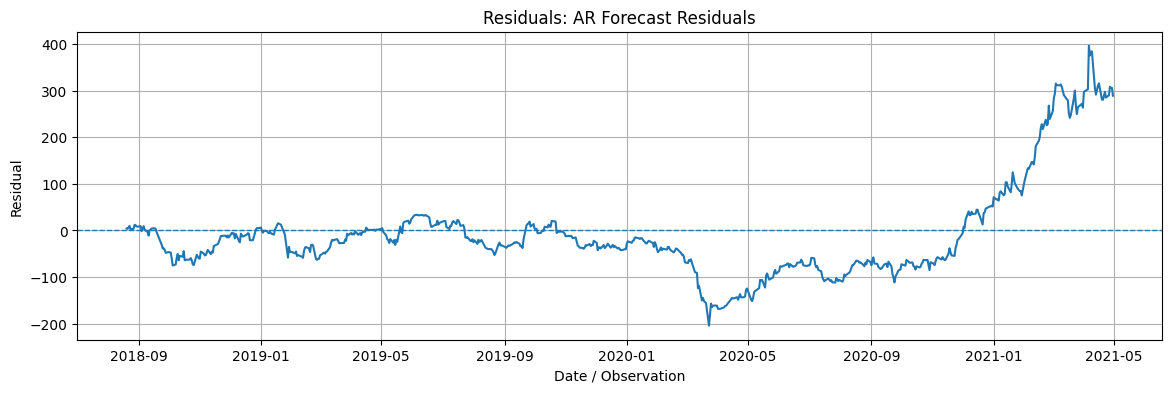

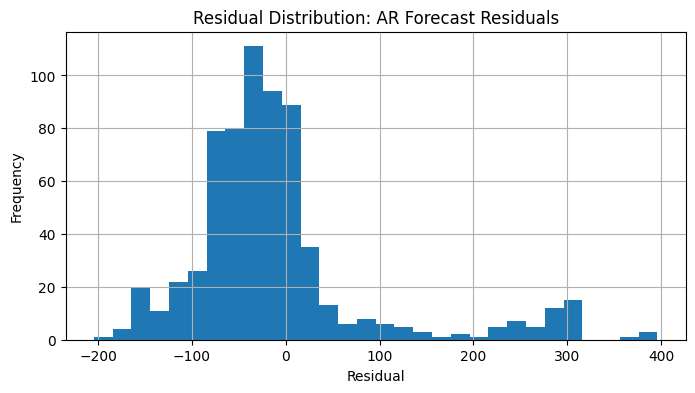

<Figure size 1400x400 with 0 Axes>

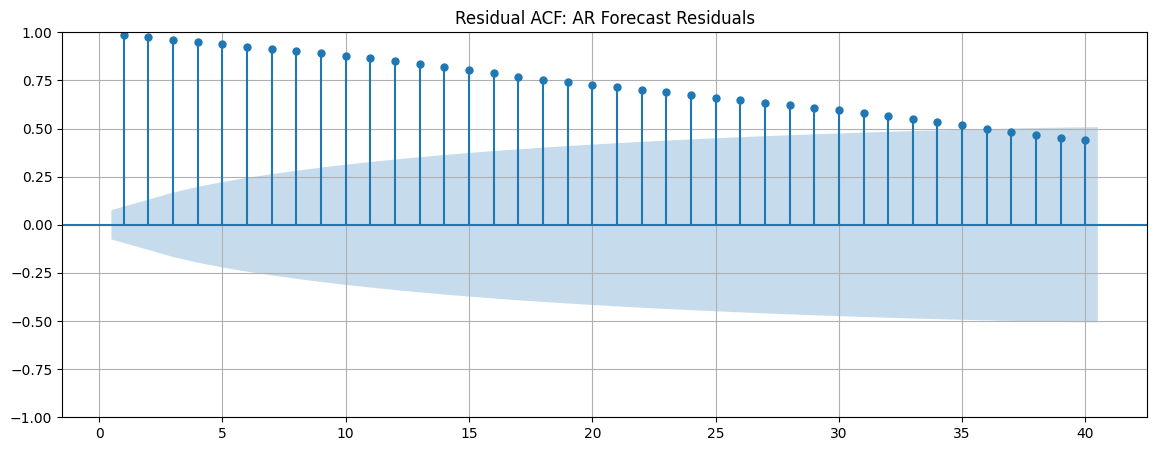

,lb_stat,lb_pvalue
5,"3,103.6649",0.0000
10,"5,849.9834",0.0000
20,"10,184.3524",0.0000


MA
Residual mean: -9.605095136085483
Residual std: 99.69093524482642


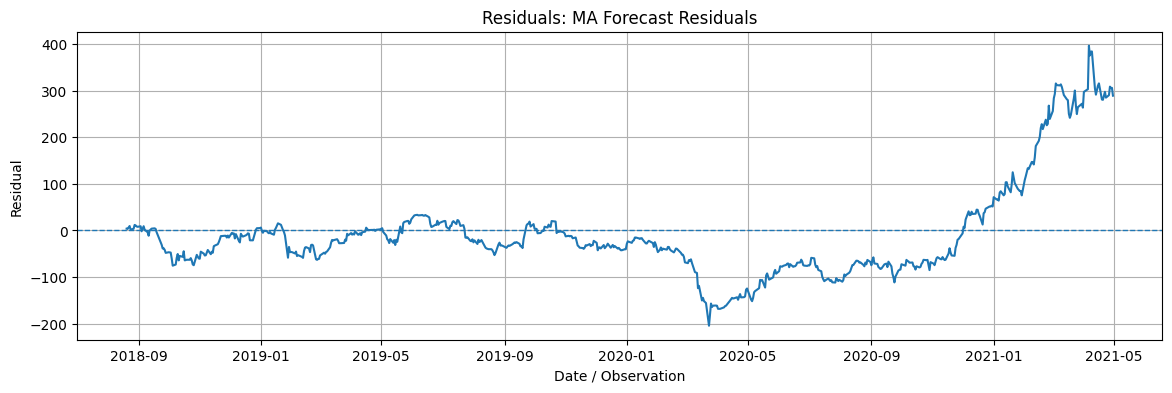

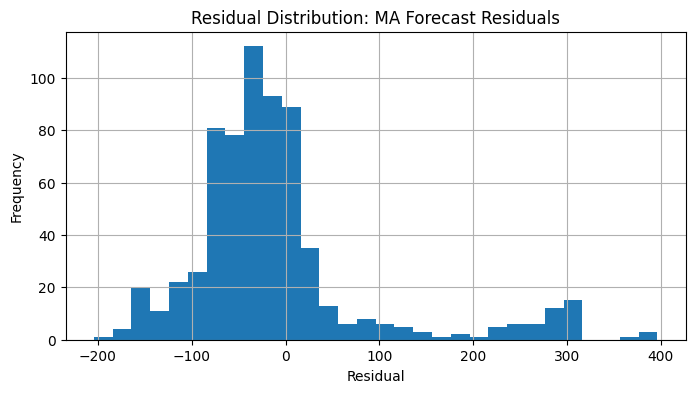

<Figure size 1400x400 with 0 Axes>

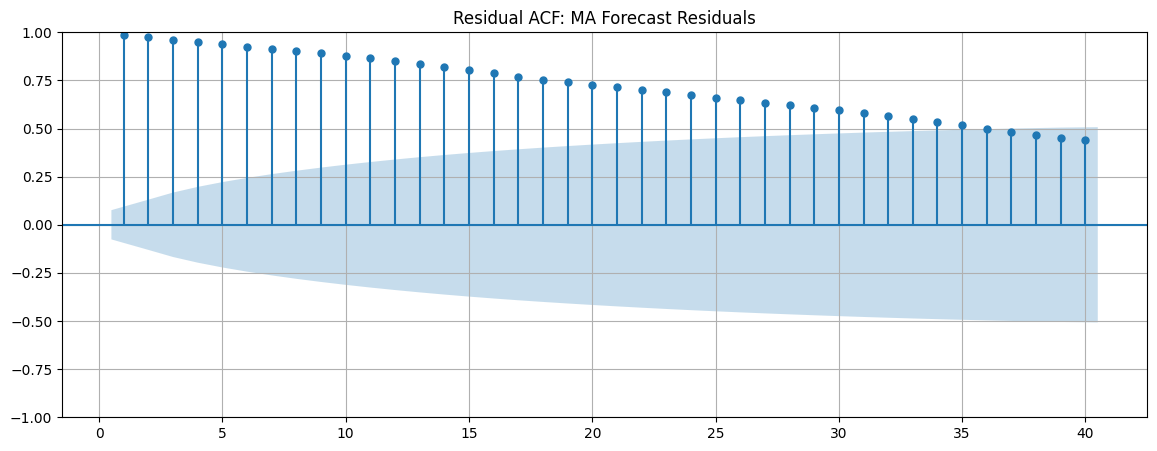

,lb_stat,lb_pvalue
5,"3,103.6804",0.0000
10,"5,850.0320",0.0000
20,"10,184.5343",0.0000


ARMA
Residual mean: -8.859593465526679
Residual std: 99.77519571967989


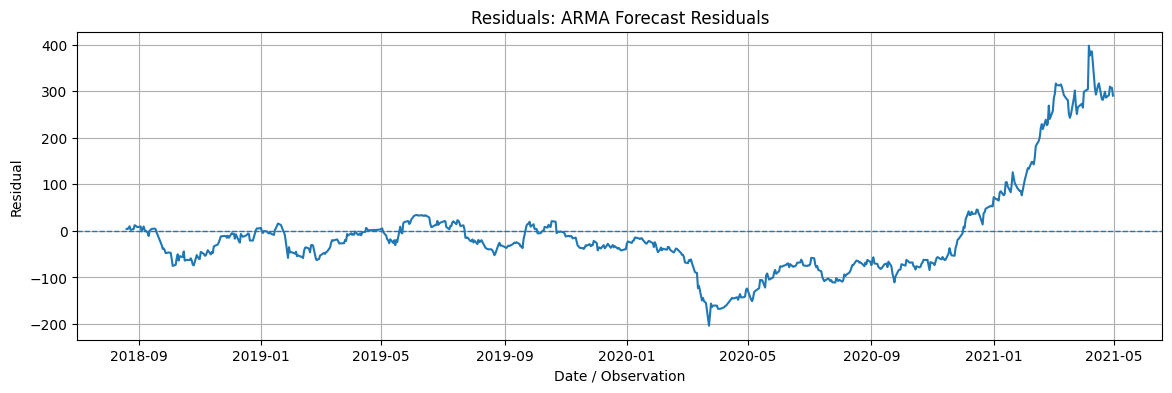

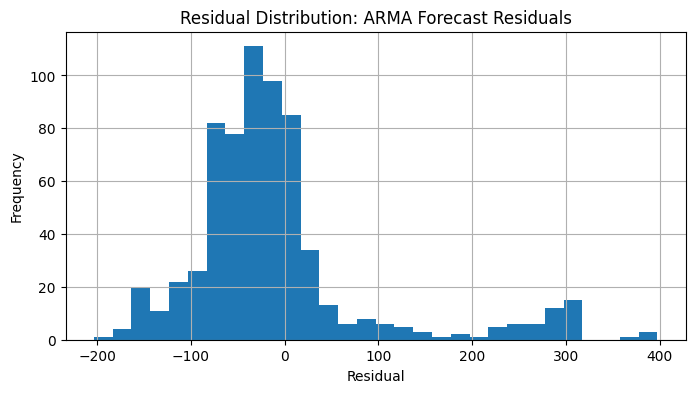

<Figure size 1400x400 with 0 Axes>

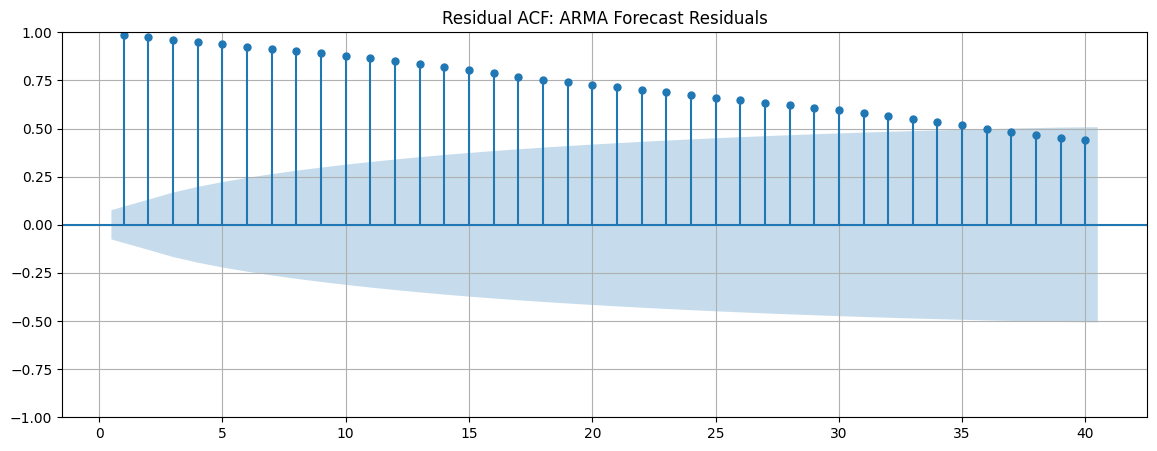

,lb_stat,lb_pvalue
5,"3,103.7199",0.0000
10,"5,850.1582",0.0000
20,"10,185.0053",0.0000


ARIMA
Residual mean: 23.042621747767217
Residual std: 107.89323384894611


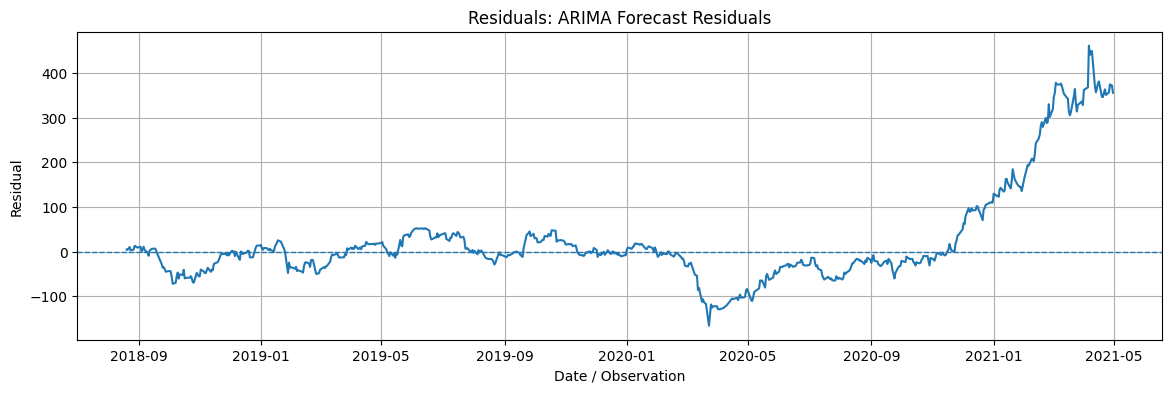

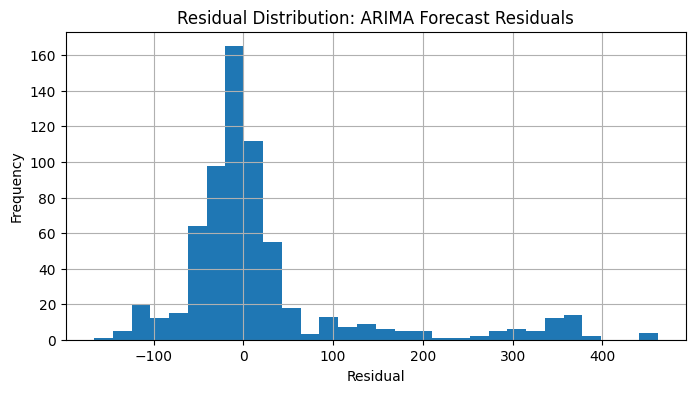

<Figure size 1400x400 with 0 Axes>

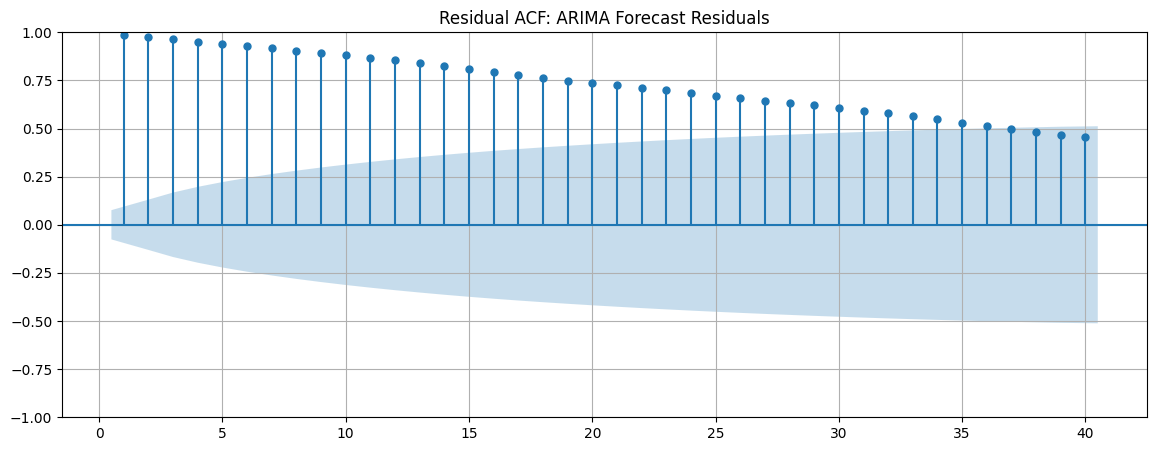

,lb_stat,lb_pvalue
5,"3,110.9596",0.0000
10,"5,874.5886",0.0000
20,"10,276.7021",0.0000


In [24]:
for model_name in ["AR", "MA", "ARMA", "ARIMA"]:
    if model_name not in forecasts:
        continue

    aligned = align_actual_prediction(test, forecasts[model_name], model_name)
    if aligned.empty:
        print(f"{model_name}: no aligned forecast values.")
        continue

    residuals = aligned["Actual"] - aligned[model_name]
    print("=" * 80)
    print(model_name)
    print("Residual mean:", residuals.mean())
    print("Residual std:", residuals.std())
    plot_residual_diagnostics(residuals, f"{model_name} Forecast Residuals")

# Part V — Deep Learning-Based Forecasting

This section implements:

1. Simple RNN.
2. LSTM.
3. GRU.

The models use input sequences of previous adjusted closing prices to predict the next adjusted closing price.

Important practical note:

Deep learning models can overfit small financial datasets.  
For this dataset, the number of observations is modest, and stock prices contain regime changes.  
Therefore, neural models should be evaluated against classical models and a naive baseline, not judged by training loss alone.

In [25]:
# Deep learning setup.
# If TensorFlow is unavailable, this section will skip gracefully.

RUN_DEEP_LEARNING = True
SEQUENCE_LENGTH = 60
EPOCHS = 30
BATCH_SIZE = 32

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
    from tensorflow.keras.callbacks import EarlyStopping

    tf.random.set_seed(42)
    np.random.seed(42)
    TF_AVAILABLE = True
    print("TensorFlow available:", tf.__version__)
except Exception as e:
    TF_AVAILABLE = False
    print("TensorFlow is not available. Deep learning section will be skipped.")
    print("Import error:", e)

TensorFlow available: 2.21.0


X_train shape: (2597, 60, 1)
X_test shape: (665, 60, 1)
Training RNN
Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0033 - val_loss: 0.0362
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021 - val_loss: 0.0321
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0024 - val_loss: 0.0259
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0024 - val_loss: 0.0263
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0031 - val_loss: 0.0340
Epoch 6/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033 - val_loss: 0.0369
Epoch 7/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034 - val_loss: 0.0235
Epoch 8/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0035 - val_loss: 0.0313
Epoch 9/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0047 - val_loss: 0.0050
Epoch 10/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0041 - val_loss: 0.0242
Epoch 11/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0022 - val_loss: 0.0205
Epoc

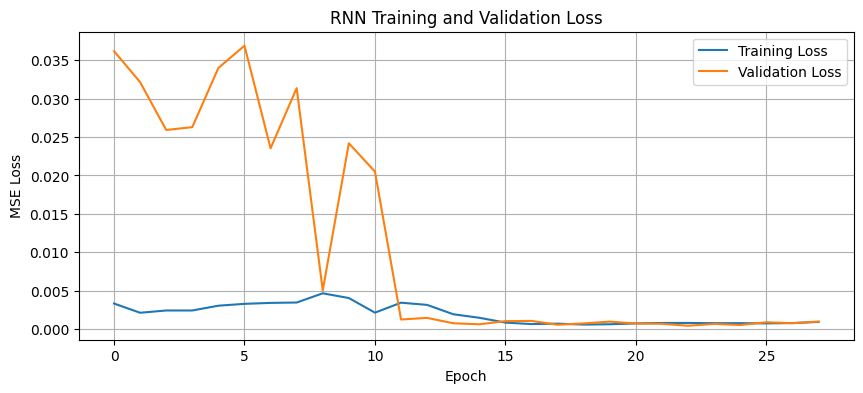

Training LSTM
Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0038 - val_loss: 0.0412
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0036 - val_loss: 0.0323
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0048 - val_loss: 0.0548
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0077 - val_loss: 0.0305
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0094 - val_loss: 0.0056


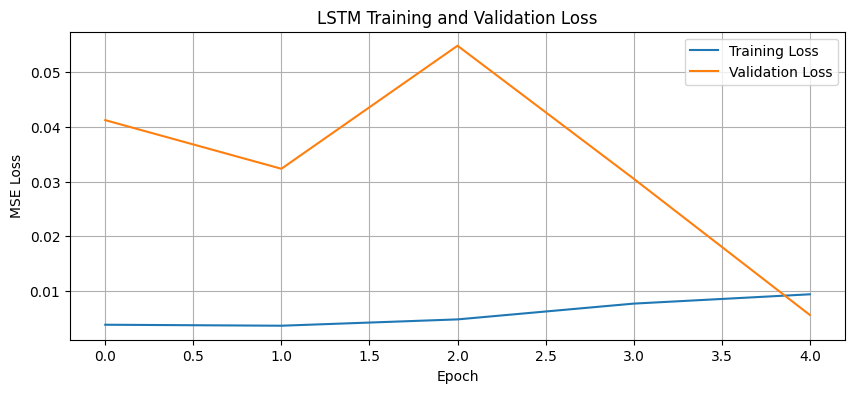

Training GRU
Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0041 - val_loss: 0.0325
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0064 - val_loss: 0.0488
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0084 - val_loss: 0.0152
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0115 - val_loss: 0.0034
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0100 - val_loss: 0.0026


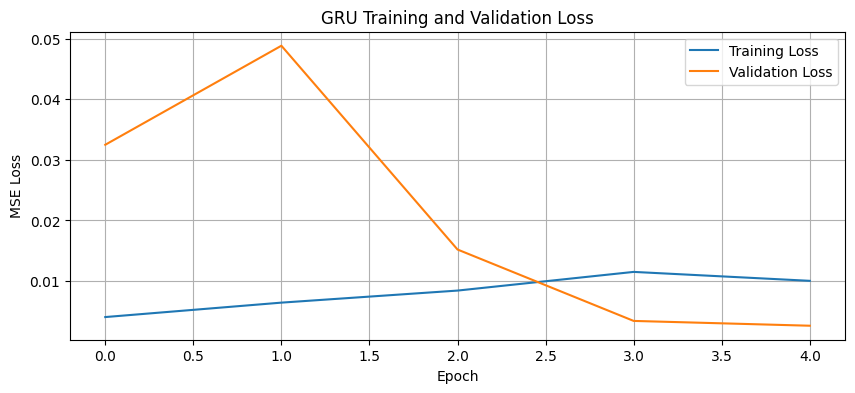

In [26]:
def create_sequences(values, sequence_length):
    X, y = [], []
    for i in range(sequence_length, len(values)):
        X.append(values[i-sequence_length:i])
        y.append(values[i])
    return np.array(X), np.array(y)


def build_rnn_model(model_type, sequence_length):
    model = Sequential()

    if model_type == "RNN":
        model.add(SimpleRNN(64, return_sequences=False, input_shape=(sequence_length, 1)))
    elif model_type == "LSTM":
        model.add(LSTM(64, return_sequences=False, input_shape=(sequence_length, 1)))
    elif model_type == "GRU":
        model.add(GRU(64, return_sequences=False, input_shape=(sequence_length, 1)))
    else:
        raise ValueError("model_type must be RNN, LSTM, or GRU")

    model.add(Dropout(0.20))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1))

    model.compile(optimizer="adam", loss="mse")
    return model


def plot_training_history(history, model_name):
    plt.figure(figsize=(10, 4))
    plt.plot(history.history["loss"], label="Training Loss")
    if "val_loss" in history.history:
        plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.show()


dl_histories = {}
dl_models = {}

if RUN_DEEP_LEARNING and TF_AVAILABLE:
    # Scale using only training data to avoid leakage.
    scaler = MinMaxScaler()
    train_values = train.values.reshape(-1, 1)
    test_values = test.values.reshape(-1, 1)

    scaler.fit(train_values)

    full_scaled = scaler.transform(series.values.reshape(-1, 1))

    # Build sequences from full data, then select those whose targets are inside train/test regions.
    X_all, y_all = create_sequences(full_scaled, SEQUENCE_LENGTH)
    target_indices = series.index[SEQUENCE_LENGTH:]

    train_mask = target_indices <= train.index[-1]
    test_mask = target_indices >= test.index[0]

    X_train_dl = X_all[train_mask]
    y_train_dl = y_all[train_mask]
    X_test_dl = X_all[test_mask]
    y_test_dl = y_all[test_mask]
    dl_test_index = target_indices[test_mask]

    print("X_train shape:", X_train_dl.shape)
    print("X_test shape:", X_test_dl.shape)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    for model_type in ["RNN", "LSTM", "GRU"]:
        print("=" * 80)
        print(f"Training {model_type}")

        model = build_rnn_model(model_type, SEQUENCE_LENGTH)
        history = model.fit(
            X_train_dl, y_train_dl,
            validation_split=0.20,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stop],
            verbose=1,
            shuffle=False
        )

        dl_models[model_type] = model
        dl_histories[model_type] = history

        plot_training_history(history, model_type)

        pred_scaled = model.predict(X_test_dl, verbose=0)
        pred_price = scaler.inverse_transform(pred_scaled).ravel()

        forecasts[model_type] = pd.Series(pred_price, index=dl_test_index)
else:
    print("Deep learning models were not run. Set RUN_DEEP_LEARNING=True and install TensorFlow if needed.")

### Deep learning architecture explanation

Each neural network uses a sequence-to-one forecasting design:

- Input: previous `60` adjusted close values.
- Output: next adjusted close value.
- Hidden layer: 64 recurrent units.
- Dropout: 20% to reduce overfitting.
- Dense layer: converts learned temporal representation into price forecast.
- Loss function: mean squared error.
- Optimizer: Adam.

Model differences:

| Model | Main idea |
|---|---|
| Simple RNN | Basic recurrent memory; can struggle with long dependencies |
| LSTM | Uses gates to preserve and forget information over longer sequences |
| GRU | Similar to LSTM but simpler and often faster |

The test forecasts are aligned to the subset of test dates for which enough lookback data exists.

# Part VI — Model Evaluation

Metrics:

| Metric | Meaning |
|---|---|
| MAE | Average absolute error in price units |
| RMSE | Penalizes large errors more strongly |
| MAPE | Average percentage error |

The evaluation function below safely aligns predictions with the actual test series.

In [27]:
def mean_absolute_percentage_error_safe(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mask = actual != 0
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100


def evaluate_forecast(actual, predicted, model_name):
    aligned = align_actual_prediction(actual, predicted, model_name)

    if aligned.empty:
        return {
            "Model": model_name,
            "Observations": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE": np.nan
        }

    y_true = aligned["Actual"]
    y_pred = aligned[model_name]

    return {
        "Model": model_name,
        "Observations": len(aligned),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mean_absolute_percentage_error_safe(y_true, y_pred)
    }


metrics = []
for model_name, pred in forecasts.items():
    metrics.append(evaluate_forecast(test, pred, model_name))

metrics_df = pd.DataFrame(metrics).sort_values("RMSE", na_position="last").reset_index(drop=True)
display(metrics_df)

,Model,Observations,MAE,RMSE,MAPE
0,RNN,665,11.4607,19.5625,2.5175
1,AR,665,67.5066,100.0565,16.5071
2,MA,665,67.4758,100.0779,16.4927
3,ARMA,665,67.2203,100.0930,16.3943
4,GRU,665,89.7450,104.9657,21.1321
5,ARIMA,665,61.2219,110.2470,13.2718
6,Naive,665,61.2175,110.2548,13.2693
7,LSTM,665,100.2049,115.8597,23.7556


# Part VII — Comparative Visualization

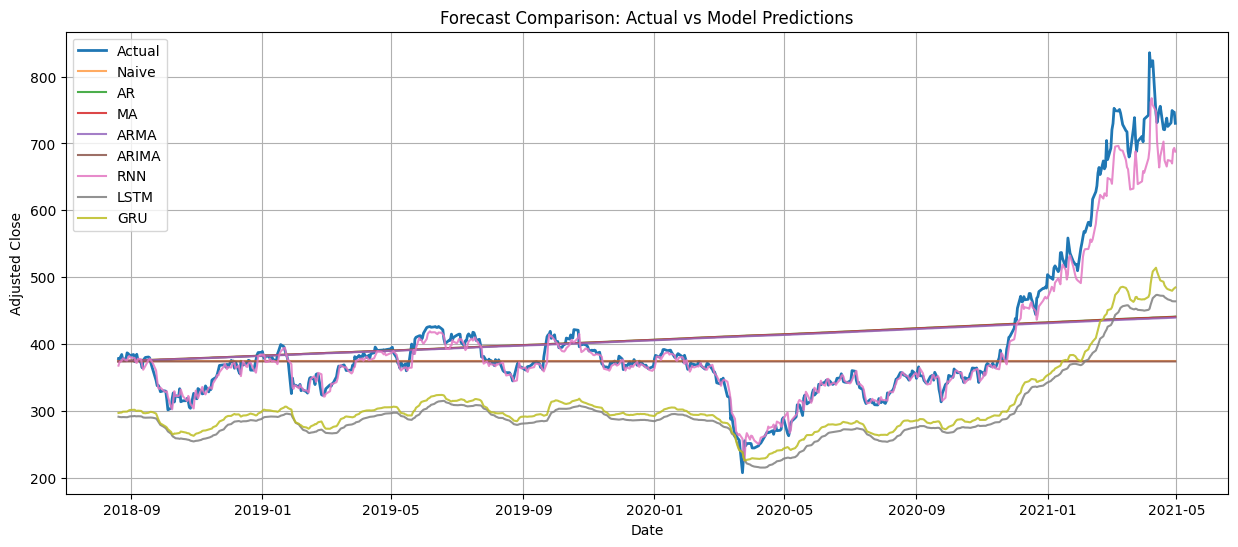

In [28]:
plt.figure(figsize=(15, 6))
plt.plot(test.index, test.values, label="Actual", linewidth=2)

for model_name, pred in forecasts.items():
    if model_name == "Naive":
        alpha = 0.65
    else:
        alpha = 0.85

    aligned = align_actual_prediction(test, pred, model_name)
    if not aligned.empty:
        plt.plot(aligned.index, aligned[model_name], label=model_name, alpha=alpha)

plt.title("Forecast Comparison: Actual vs Model Predictions")
plt.xlabel("Date")
plt.ylabel("Adjusted Close")
plt.legend()
plt.show()

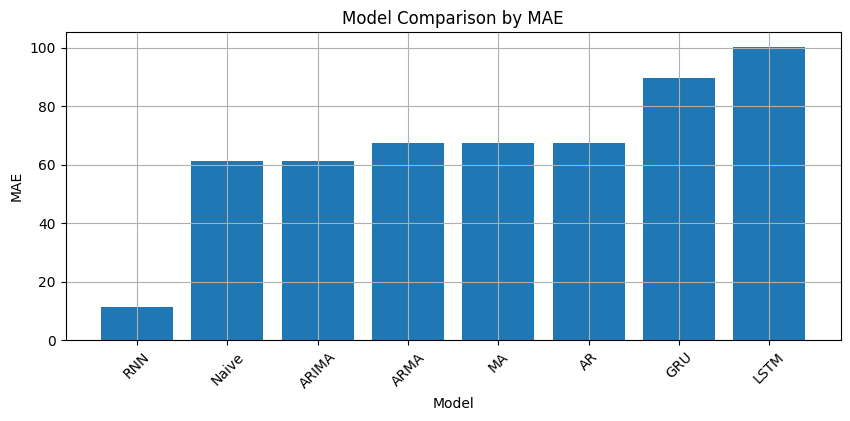

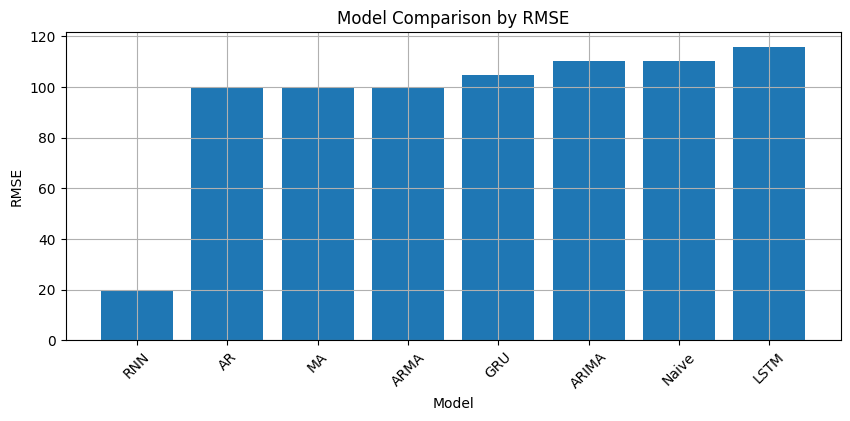

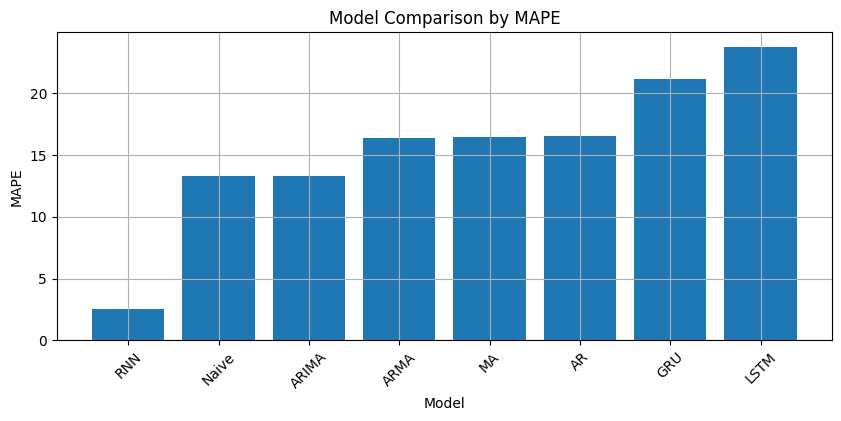

In [29]:
if len(metrics_df.dropna(subset=["MAE", "RMSE", "MAPE"])) > 0:
    for metric in ["MAE", "RMSE", "MAPE"]:
        plt.figure(figsize=(10, 4))
        plot_df = metrics_df.dropna(subset=[metric]).sort_values(metric)
        plt.bar(plot_df["Model"], plot_df[metric])
        plt.title(f"Model Comparison by {metric}")
        plt.xlabel("Model")
        plt.ylabel(metric)
        plt.xticks(rotation=45)
        plt.show()

## Residual analysis for all available models

Residuals are calculated as:

\[
e_t = y_t - \hat{y}_t
\]

The residual ACF helps determine whether forecast errors still contain systematic autocorrelation.  
If residual ACF values are mostly inside the confidence band and Ljung-Box p-values are high, the residuals are closer to white noise.

Residual diagnostics for Naive
Number of residuals: 665
Mean residual: 23.07947368421051
Std residual: 107.89327329431772


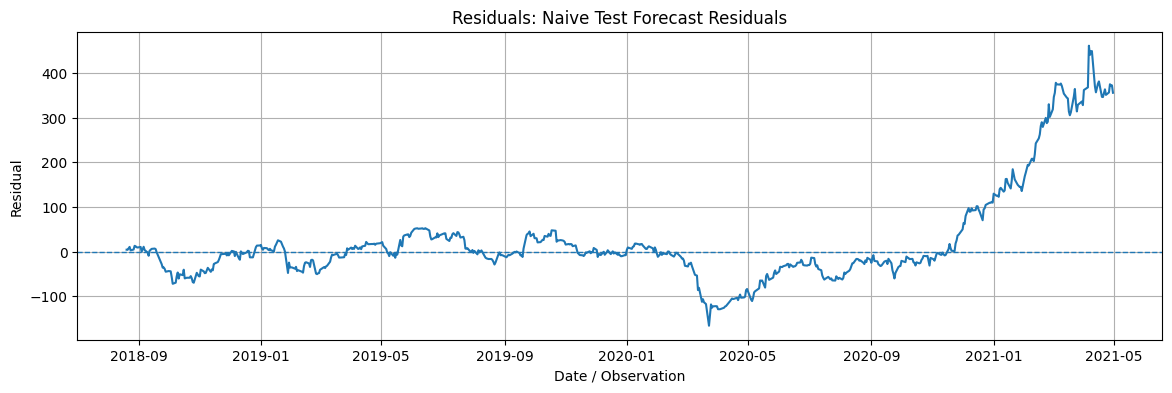

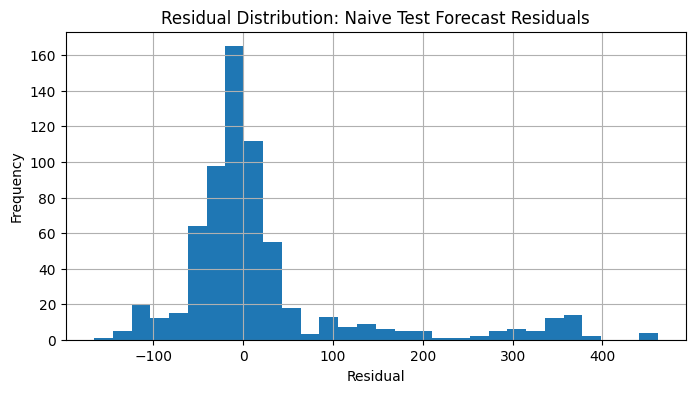

<Figure size 1400x400 with 0 Axes>

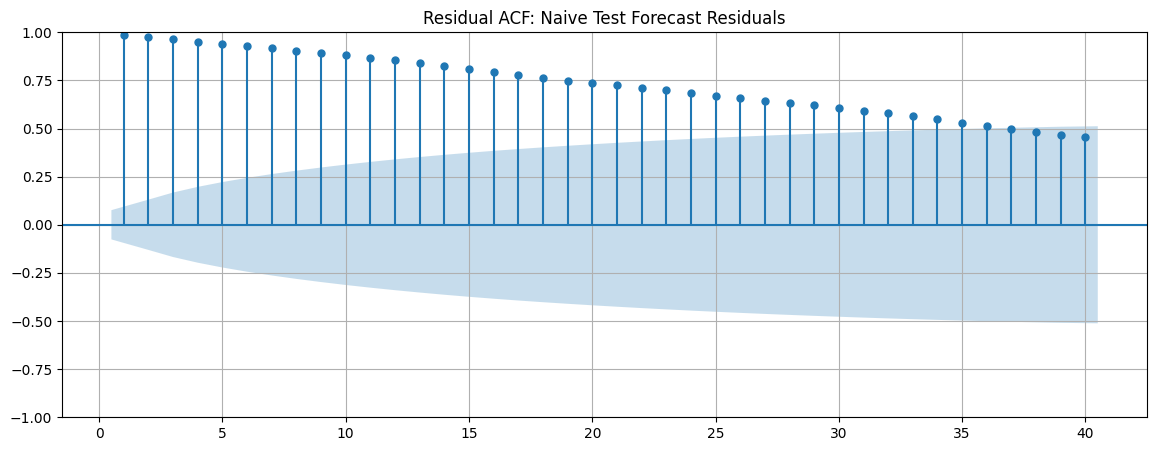

,lb_stat,lb_pvalue
5,"3,110.9542",0.0000
10,"5,874.5798",0.0000
20,"10,276.6859",0.0000


Residual diagnostics for AR
Number of residuals: 665
Mean residual: -9.728145604527867
Std residual: 99.6573823145


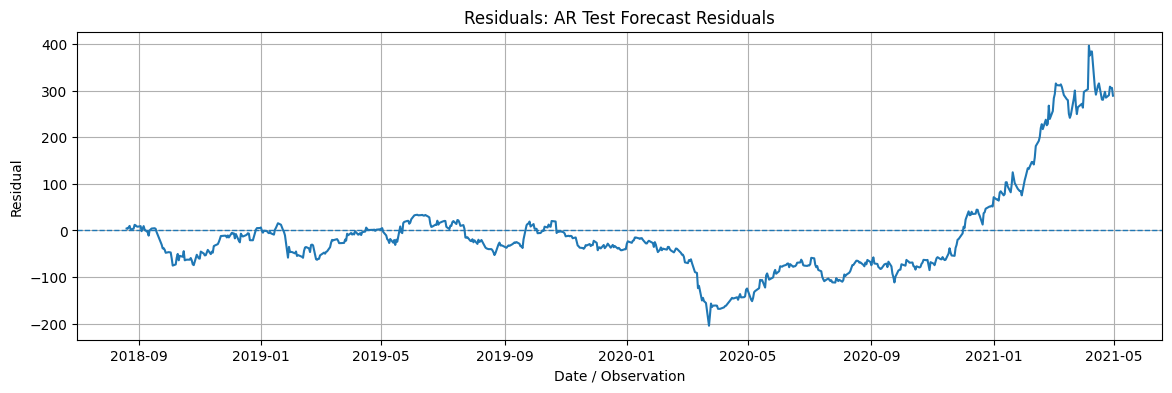

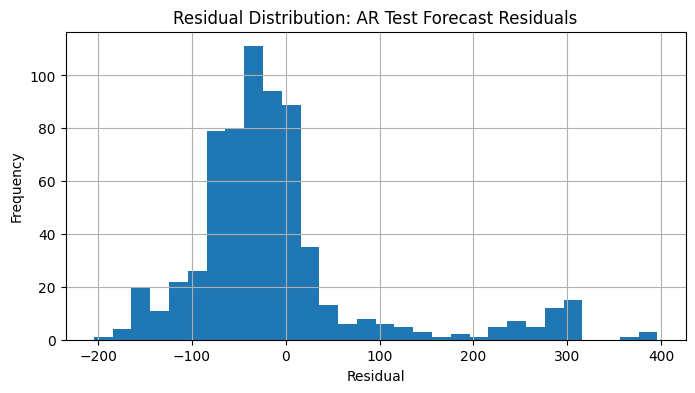

<Figure size 1400x400 with 0 Axes>

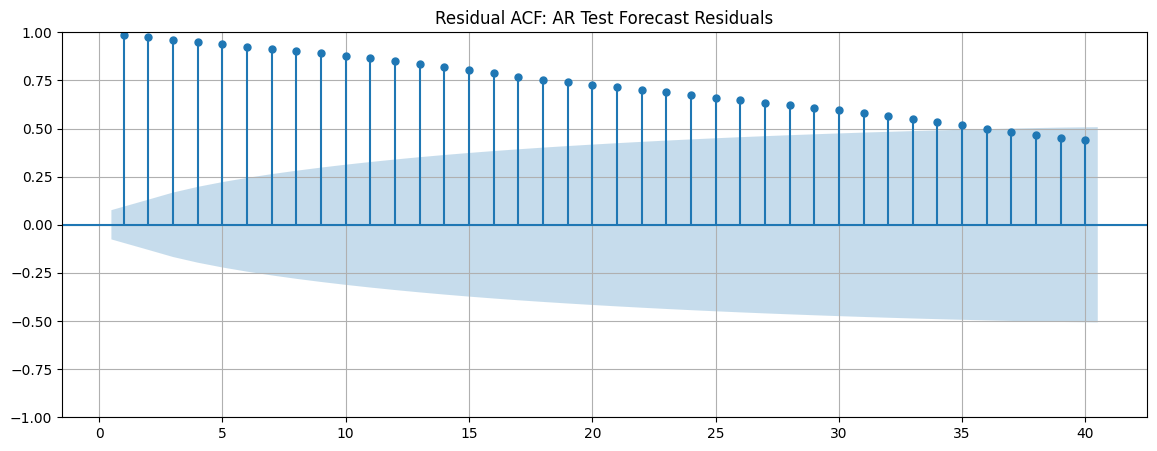

,lb_stat,lb_pvalue
5,"3,103.6649",0.0000
10,"5,849.9834",0.0000
20,"10,184.3524",0.0000


Residual diagnostics for MA
Number of residuals: 665
Mean residual: -9.605095136085483
Std residual: 99.69093524482642


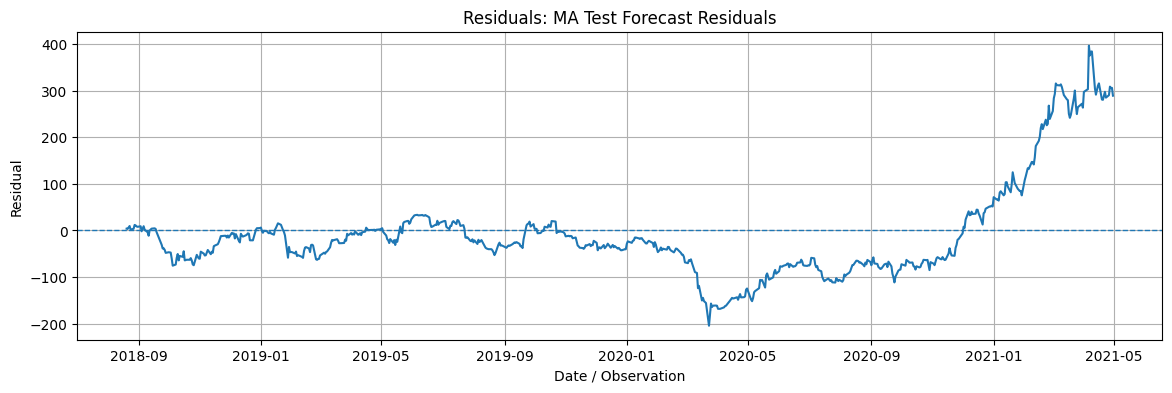

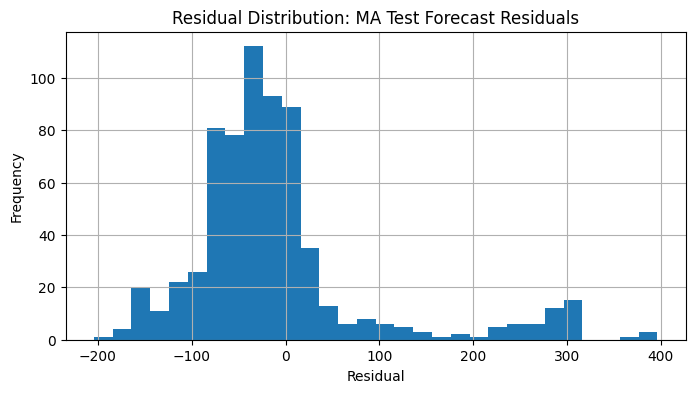

<Figure size 1400x400 with 0 Axes>

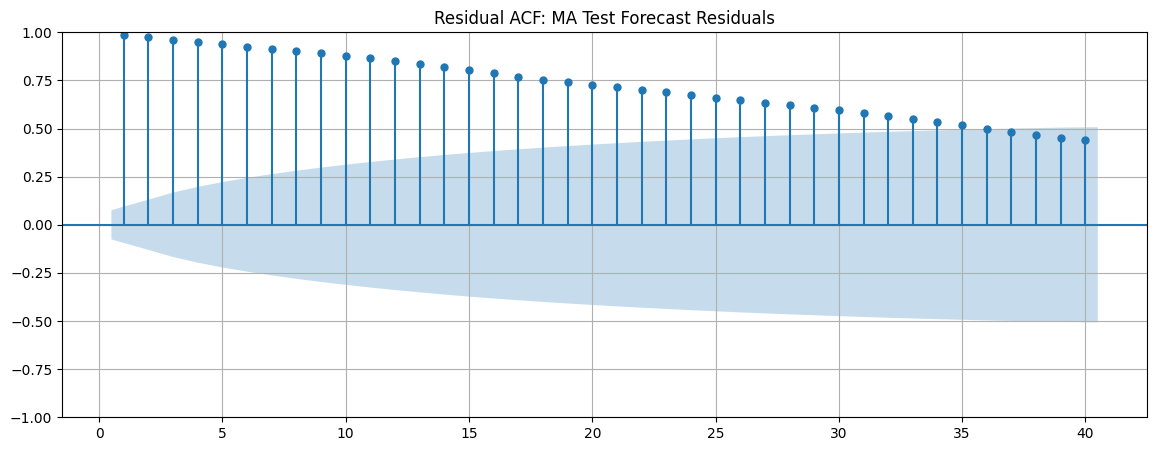

,lb_stat,lb_pvalue
5,"3,103.6804",0.0000
10,"5,850.0320",0.0000
20,"10,184.5343",0.0000


Residual diagnostics for ARMA
Number of residuals: 665
Mean residual: -8.859593465526679
Std residual: 99.77519571967989


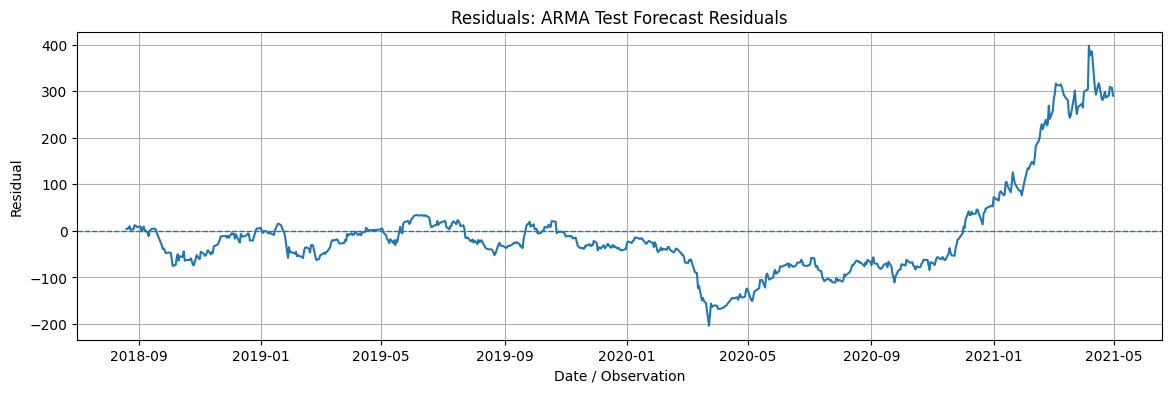

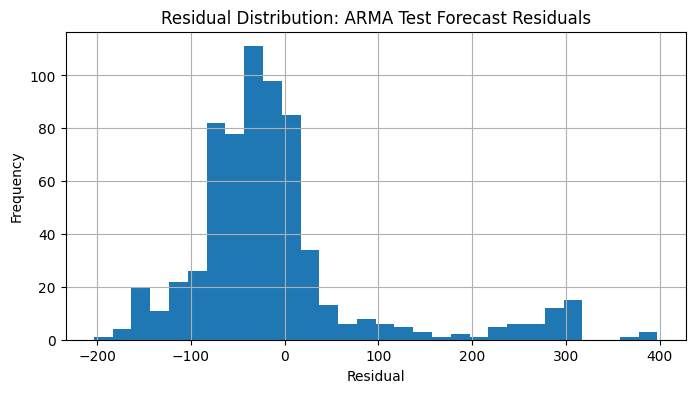

<Figure size 1400x400 with 0 Axes>

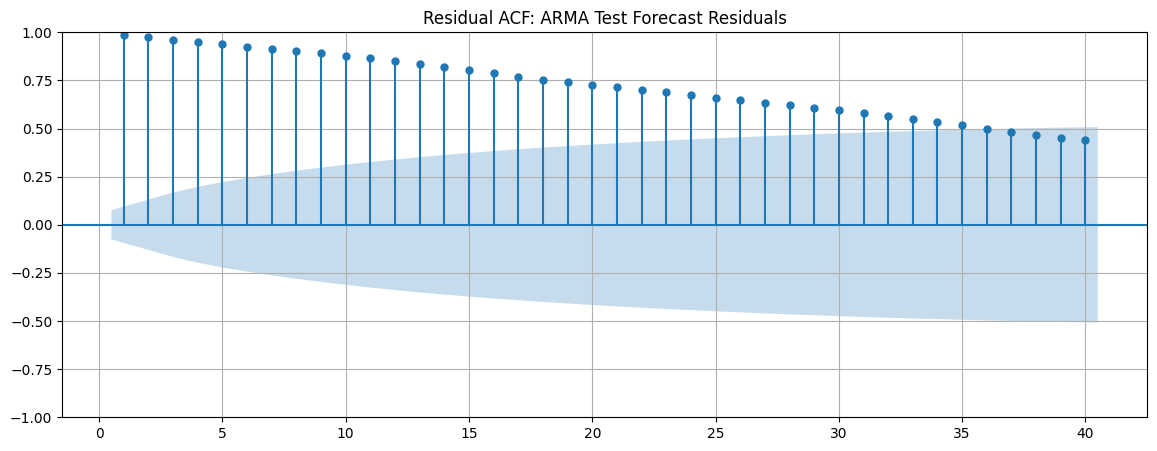

,lb_stat,lb_pvalue
5,"3,103.7199",0.0000
10,"5,850.1582",0.0000
20,"10,185.0053",0.0000


Residual diagnostics for ARIMA
Number of residuals: 665
Mean residual: 23.042621747767217
Std residual: 107.89323384894611


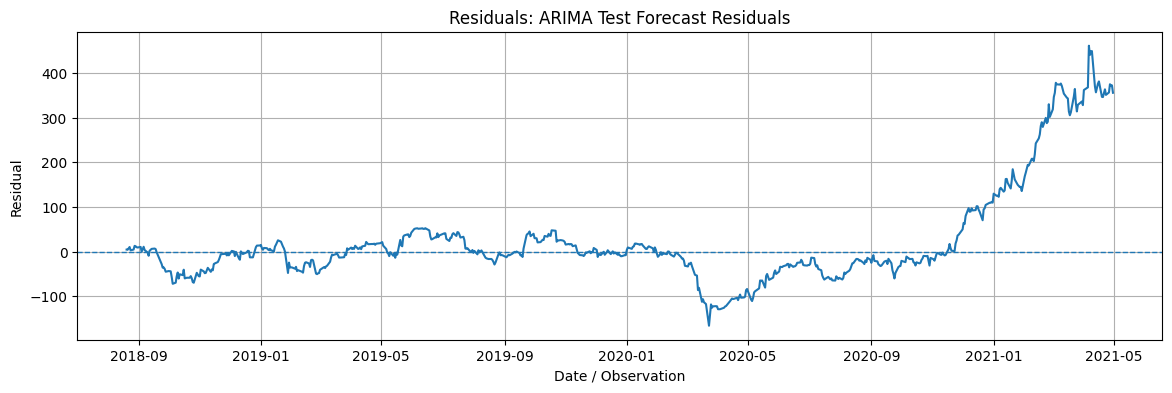

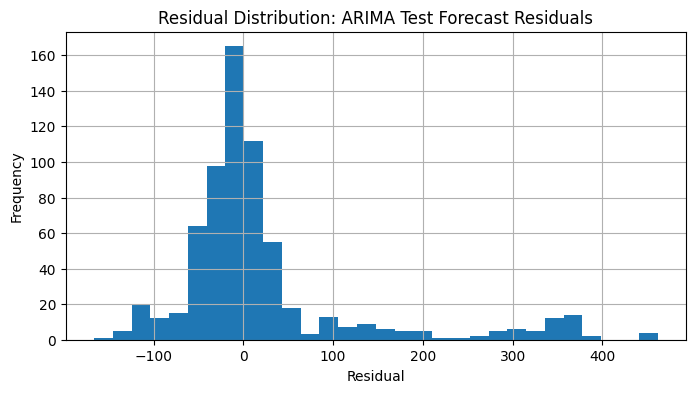

<Figure size 1400x400 with 0 Axes>

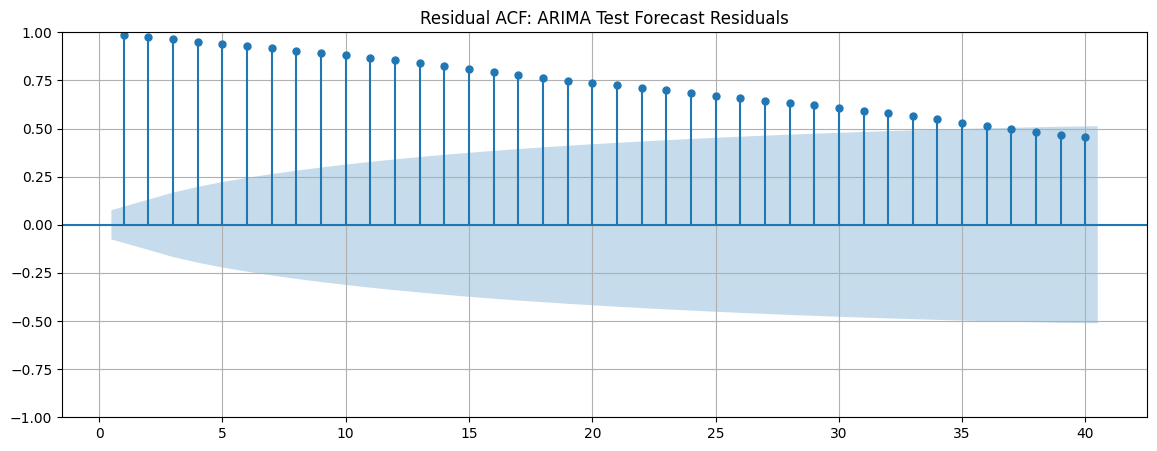

,lb_stat,lb_pvalue
5,"3,110.9596",0.0000
10,"5,874.5886",0.0000
20,"10,276.7021",0.0000


Residual diagnostics for RNN
Number of residuals: 665
Mean residual: 7.443911458639273
Std residual: 18.104468309802254


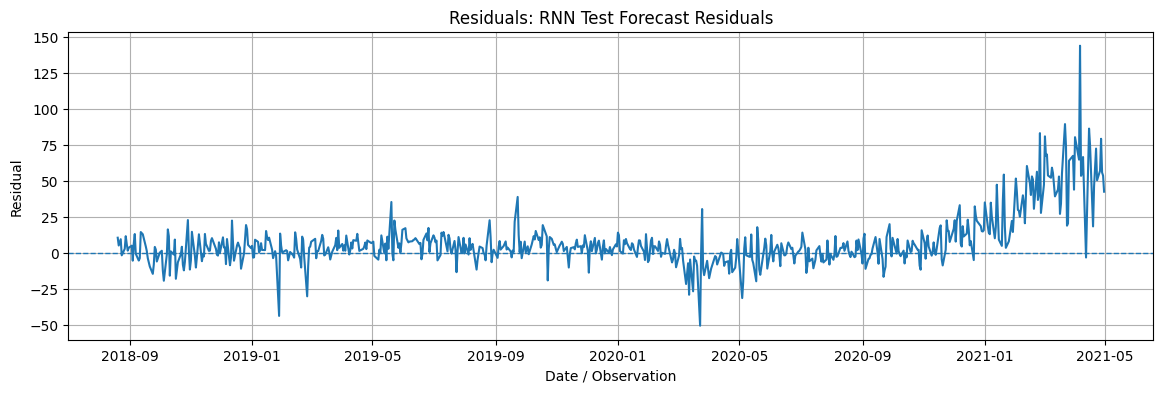

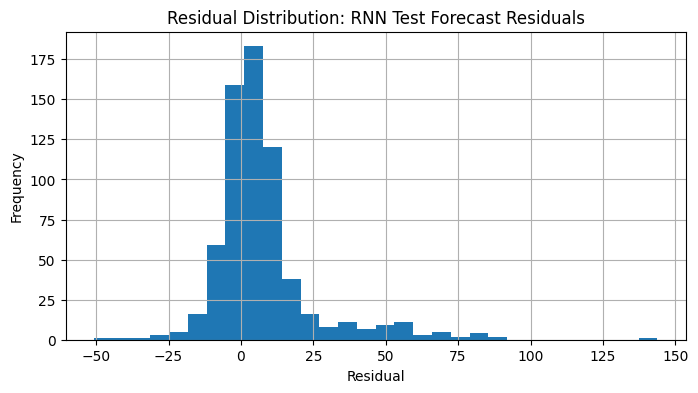

<Figure size 1400x400 with 0 Axes>

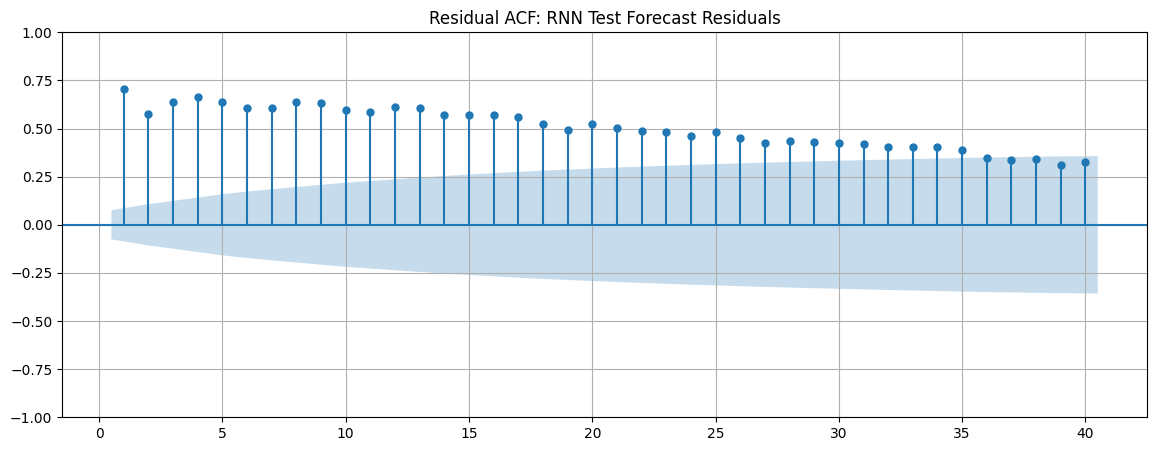

,lb_stat,lb_pvalue
5,"1,398.3375",0.0000
10,"2,676.0857",0.0000
20,"4,840.1878",0.0000


Residual diagnostics for LSTM
Number of residuals: 665
Mean residual: 100.10993805161097
Std residual: 58.3660138672742


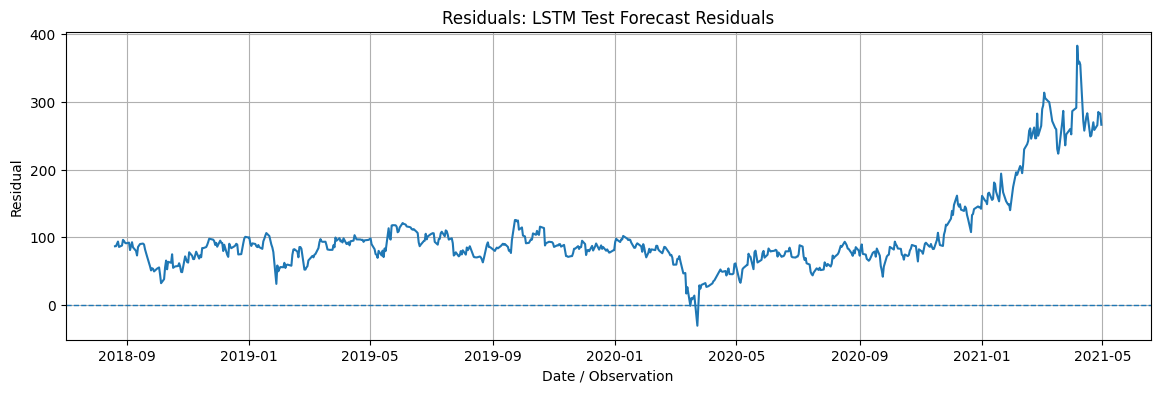

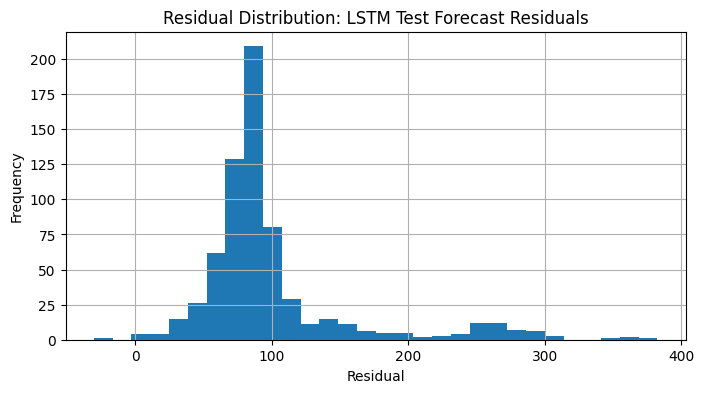

<Figure size 1400x400 with 0 Axes>

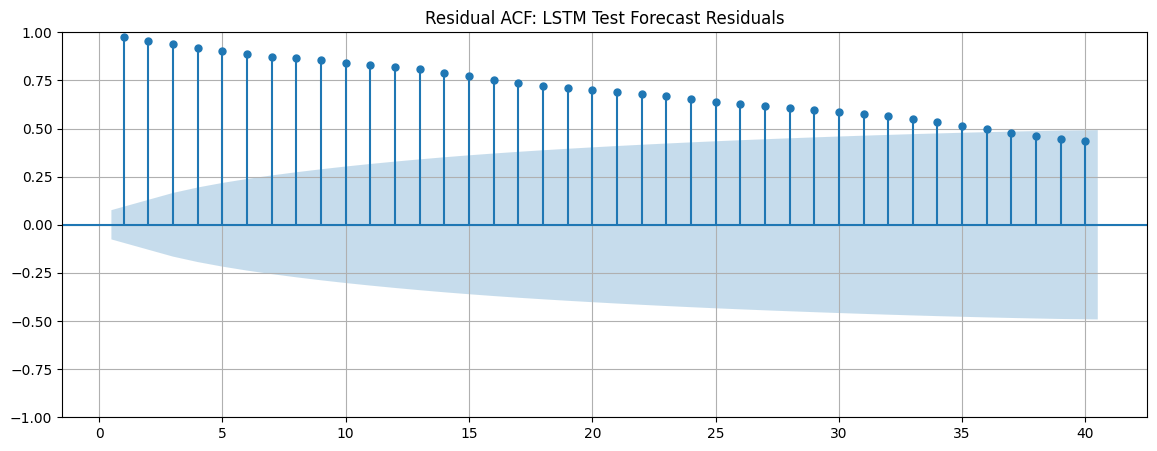

,lb_stat,lb_pvalue
5,"2,948.2623",0.0000
10,"5,469.0437",0.0000
20,"9,463.6472",0.0000


Residual diagnostics for GRU
Number of residuals: 665
Mean residual: 89.64651144156778
Std residual: 54.64233837423758


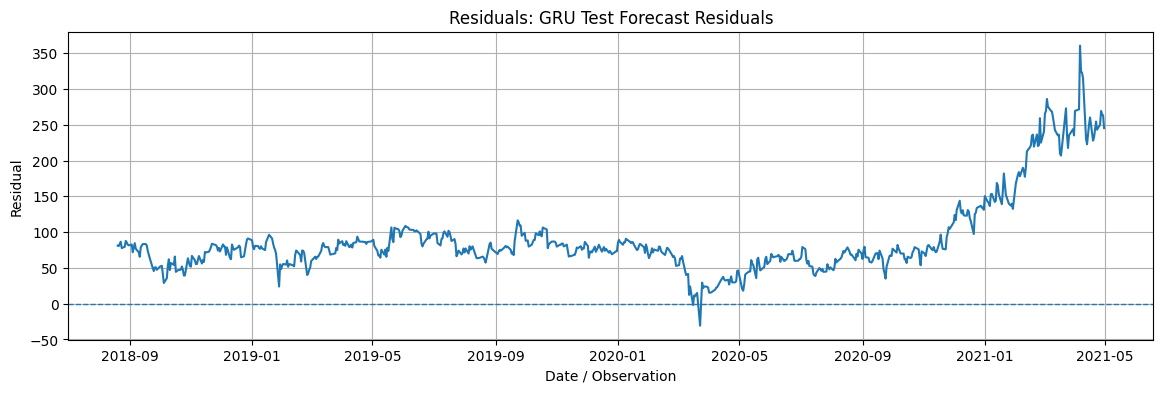

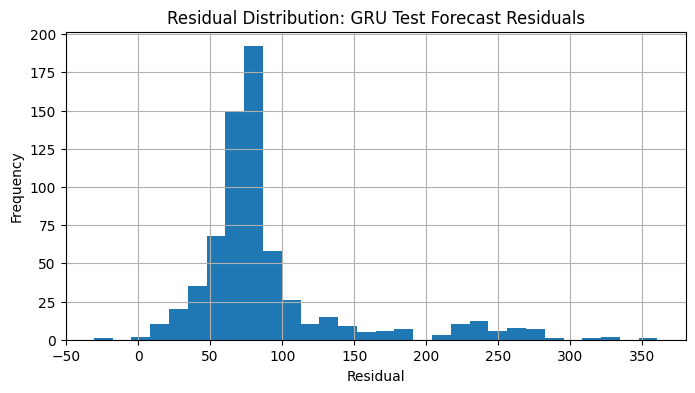

<Figure size 1400x400 with 0 Axes>

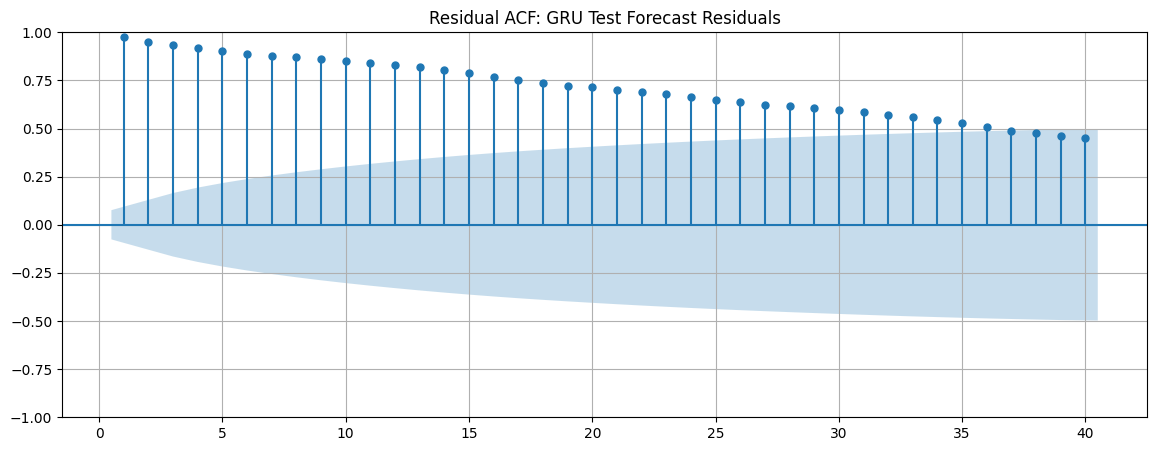

,lb_stat,lb_pvalue
5,"2,933.9401",0.0000
10,"5,492.3139",0.0000
20,"9,635.6602",0.0000


In [30]:
forecast_residuals = {}

for model_name, pred in forecasts.items():
    aligned = align_actual_prediction(test, pred, model_name)

    if aligned.empty:
        print(f"Skipping {model_name}: no aligned values.")
        continue

    residuals = aligned["Actual"] - aligned[model_name]
    residuals = residuals.replace([np.inf, -np.inf], np.nan).dropna()

    if len(residuals) == 0:
        print(f"Skipping {model_name}: residuals empty after cleaning.")
        continue

    forecast_residuals[model_name] = residuals

for model_name, residuals in forecast_residuals.items():
    print("=" * 80)
    print(f"Residual diagnostics for {model_name}")
    print("Number of residuals:", len(residuals))
    print("Mean residual:", residuals.mean())
    print("Std residual:", residuals.std())
    plot_residual_diagnostics(residuals, f"{model_name} Test Forecast Residuals")

# Part VIII — Discussion and Conclusions

## What caused the wrong trend result?

The earlier downward trend conclusion was mainly caused by a **split-like price scale discontinuity** around 2010-09-23.

The raw closing price dropped from roughly `837` to roughly `165.6`, a ratio of about `5`.  
A simple regression on unadjusted raw close prices interpreted this as an economic decline, even though it is better treated as a scale adjustment.

After adjusting the pre-event prices, the trend analysis becomes consistent with the visual evidence: the adjusted series shows a long-term upward trend.

## Did ACF and PACF correctly guide model order selection?

ACF and PACF are useful only after stationarity is achieved.  
On the raw price level, they are misleading because the series is non-stationary.  
On log returns, they show whether meaningful AR or MA structure remains.

For this dataset, the return autocorrelation is likely weak, so ACF/PACF may suggest only low-order AR and MA components.  
That means AR, MA, and ARMA models may have limited forecasting power.

## How did AR, MA, ARMA, and ARIMA compare against RNN-based forecasting?

Use the metric table to decide empirically.

Common outcome for stock price data:

- Classical models are stable and interpretable.
- Deep learning models may fit nonlinear patterns but can overfit.
- A naive/random-walk baseline is difficult to beat if the stock behaves close to an efficient market process.
- Deep learning models may look good when the test period has a strong trend, but that does not always imply robust future generalization.

## Advantages of classical statistical models

- Interpretable.
- Fast to train.
- Suitable for small datasets.
- Strong diagnostics through residual analysis.
- Good when the series has simple autocorrelation structure.

## Limitations of classical statistical models

- Usually linear.
- Sensitive to structural breaks if not corrected.
- Limited ability to model nonlinear regime changes.
- AR/MA/ARMA require stationarity.

## Advantages of deep learning models

- Can learn nonlinear temporal patterns.
- LSTM and GRU can model longer sequence dependencies.
- Flexible architecture.

## Limitations of deep learning models

- Require more data.
- Can overfit easily.
- Less interpretable.
- Sensitive to scaling, sequence length, random seed, and validation design.
- Training loss alone is not a reliable measure of forecasting quality.

## When to prefer ARIMA over RNN

Prefer ARIMA when:

- The dataset is small.
- Interpretability is important.
- The series has clear stationarity after differencing.
- The objective is a transparent statistical benchmark.
- You need fast and reproducible modelling.

## When to prefer RNN/LSTM/GRU over ARIMA

Prefer deep learning when:

- You have large amounts of data.
- Multiple input features are available.
- Nonlinear relationships are expected.
- You can validate carefully across multiple time periods.
- Forecast accuracy matters more than interpretability.

## Final corrected conclusion

For this ADANIPORTS dataset, the main analytical fix is not simply changing the model.  
The main fix is correcting the data representation.

The correct workflow is:

1. Detect and adjust the split-like price discontinuity.
2. Use adjusted close as the target.
3. Analyse trend by regime, not only with one raw full-sample line.
4. Use log returns for stationarity, ACF, and PACF.
5. Fit classical models on stationary returns or ARIMA on log prices.
6. Compare all models against a naive baseline.
7. Interpret trading activity only after accounting for missing `Trades` and split-adjusted volume.

This produces a more defensible and market-aware time series analysis.